# 🔎 Embedding Models in RAG Systems

Embedding models convert **text, images, or other content** into numerical vectors that capture their **semantic meaning**.

These vectors allow machines to understand **similarity between pieces of content** beyond simple keyword matching.

In a **Retrieval-Augmented Generation (RAG)** system, embeddings enable the retriever to search through large collections of **unstructured data** and find information that is most relevant to the user's question.

## 📌 Role of Embeddings in RAG

In a RAG pipeline, embeddings are used for **semantic search**.

### How it works

1. The **retriever converts the user query into a vector embedding**.
2. This vector is compared with vectors stored in a **vector database**.
3. The system calculates the **distance between vectors**.
4. Smaller distance means **higher semantic similarity**.
5. The most relevant results are selected and passed to the **LLM context window**.

> ⚠️ Since LLMs have a **limited context window**, only the most relevant chunks are selected.

## 🔄 Embedding-Based Retrieval Flow

A typical embedding-based retrieval process includes the following steps:

### Step 1 — Document Processing
Split large documents into **smaller chunks** and generate embeddings for each chunk.

### Step 2 — Query Embedding
Convert the **incoming user query** into an embedding using the **same embedding model**.

### Step 3 — Similarity Calculation
Compute the **distance between the query vector and stored vectors** in the vector database.

### Step 4 — Retrieve Relevant Context
Retrieve the **closest chunks** based on similarity score.

### Step 5 — Provide Context to LLM
Pass the retrieved chunks as **context to the LLM** so it can generate a more accurate response.

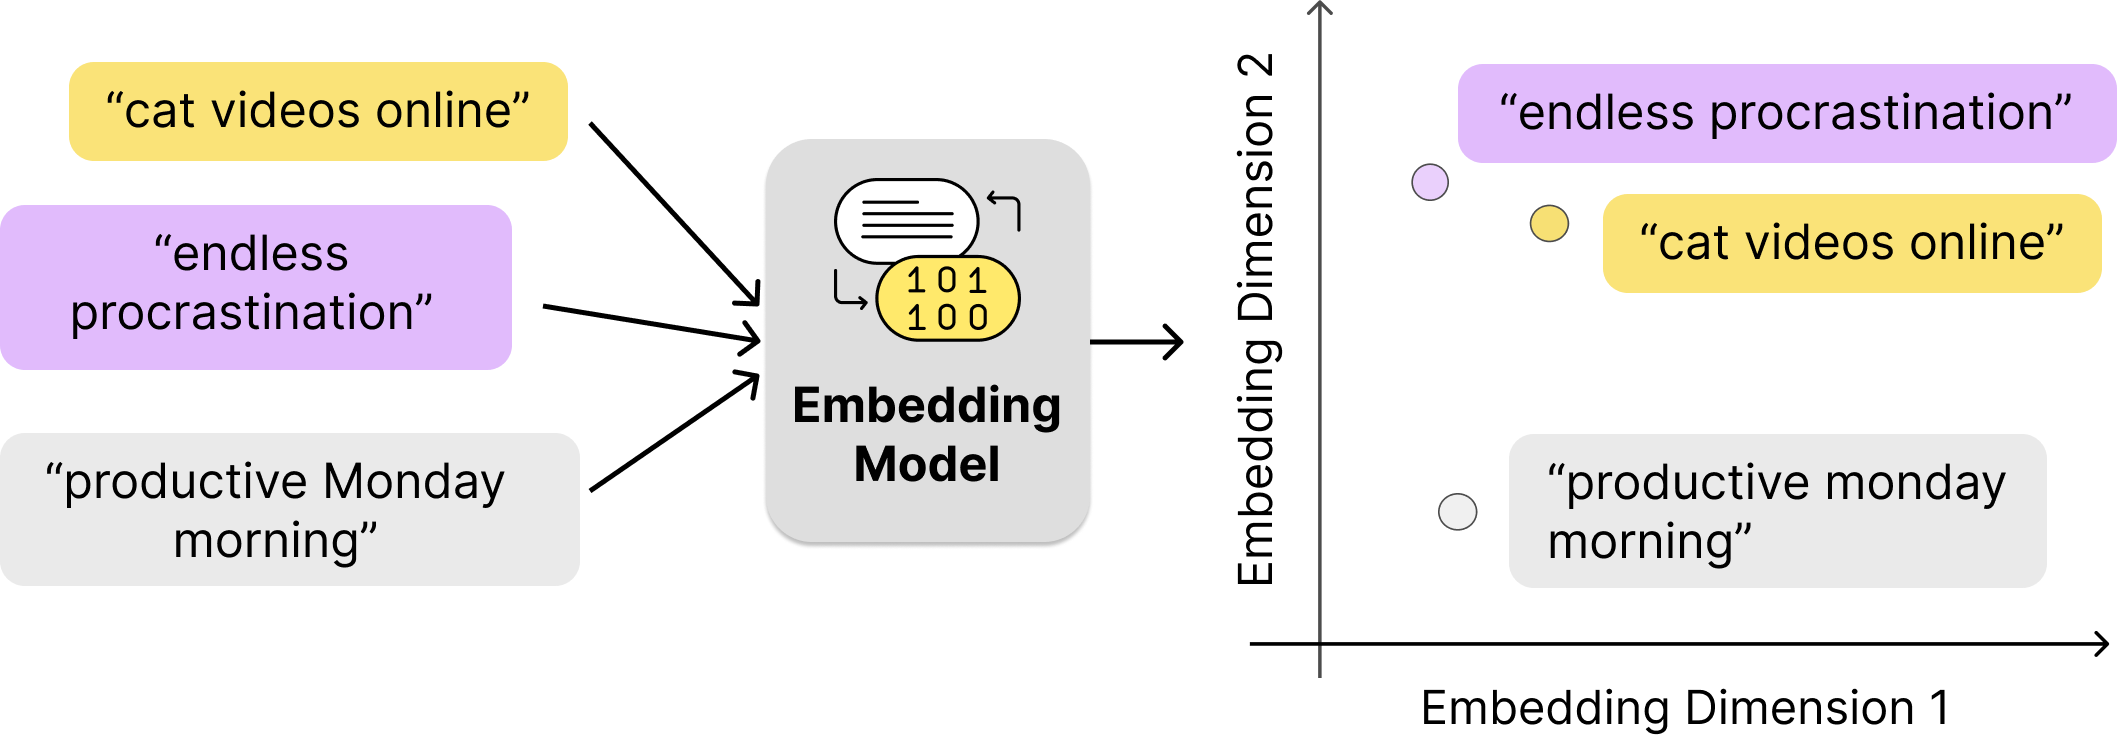

In [4]:
from IPython.display import Image, display
display(Image(filename="images/rwpc_0501.png", width=500, height=500))

#Mapping the Linguistic Meaning of Text Chunks to a Numerical Representation

## 🎯 Problem
You want to **map the semantic meaning of words and sentences into a numerical representation** so that machines can understand and compare text based on meaning rather than just keywords.

## 💡 Solution

Use an **embedding model** to convert text into **numerical vectors**.

Embedding models transform words, sentences, or entire documents into **high-dimensional vectors** that capture their **semantic meaning**.

These vectors allow machines to measure **similarity between pieces of text**.

For example:
- Sentences with **similar meaning** will be placed **closer together** in the embedding space.
- Sentences with **different meaning** will be **farther apart**.

## 🧠 Key Concept: Embedding Space

An **embedding space** is a high-dimensional numerical space where each text chunk is represented as a vector.

In this space:

✔ Similar meanings → **short distance between vectors**  
✔ Different meanings → **large distance between vectors**

This property makes embeddings extremely useful for:

- Semantic search
- Retrieval-Augmented Generation (RAG)
- Question answering systems
- Recommendation systems


## 📊 Popular Embedding Models Comparison

| **Model** | **Company** | **Platform** | **Max Tokens** | **Dimensions** |
|-----------|-------------|--------------|---------------|---------------|
| `text-embedding-3-small` | OpenAI | OpenAI API | **8191** | **1536** |
| `voyage-large-2` | Voyage AI | Voyage API | **16000** | **1536** |
| `text-embedding-004` | Google | Gemini API | **2048** | **768** |
| `all-MiniLM-L6-v2` | Open Source | Hugging Face | **512** | **384** |

In [5]:
#pip install openai sentence-transformers

In [ ]:
!pip install sentence-transformers==4.1.0
!pip install requests==2.32.3
!pip install matplotlib==3.10.3
!pip install openai==1.79.0
!pip install langchain-openai==0.3.17
!pip install pandas==2.2.3
!pip install rank-bm25
!pip install langchain_text_splitters
!pip install openai==1.83.0
!pip install PyPDF2==3.0.1

  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached torch-2.10.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (31 kB)
  Using cached scipy-1.17.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached huggingface_hub-1.4.1-py3-none-any.whl.metadata (13 kB)
  Using cached pillow-12.1.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached filelock-3.24.3-py3-none-any.whl.metadata (2.0 kB)
  Using cached numpy-2.4.2-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached pyyaml-6.0.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.4 kB)
  Using cached regex-2026.2.19-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (40 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Usi

### Load sample files

This notebook uses sample Word and PDF files.

When running the notebook on Google Colab, uncomment the code below to download the `datasets` directory from the Github repo.

In [ ]:
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    !git clone --no-checkout https://github.com/polzerdo55862/RAG-with-Python-Cookbook.git
    %cd RAG-with-Python-Cookbook
    !git sparse-checkout init --cone
    !git sparse-checkout set datasets
    !git checkout
    !cp -r datasets /content/datasets
    print("\u2713 Datasets downloaded to /content/datasets")
else:
    print("\u26a0 Running locally. Using ../datasets/ directory")

Cloning into 'RAG-with-Python-Cookbook'...
remote: Enumerating objects: 1649, done.
remote: Counting objects: 100% (389/389), done.
remote: Compressing objects: 100% (195/195), done.
remote: Total 1649 (delta 257), reused 249 (delta 190), pack-reused 1260 (from 2)
Receiving objects: 100% (1649/1649), 42.81 MiB | 10.92 MiB/s, done.
Resolving deltas: 100% (941/941), done.
/content/RAG-with-Python-Cookbook
Updating files: 100% (88/88), done.
Your branch is up to date with 'origin/main'.
✓ Datasets downloaded to /content/datasets


### Load secrets

If you run this code in Google Colab, save your OpenAI API key in the secrets and access it by

In [ ]:
import os
import sys
from dotenv import load_dotenv

# Check if running in Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    try:
        from google.colab import userdata  # type: ignore

        os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
        os.environ["ANTHROPIC_API_KEY"] = userdata.get("ANTHROPIC_API_KEY")
        os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")
    except ModuleNotFoundError:
        pass
else:
    load_dotenv()

### How to generate embeddings using the OpenAI and HuggingFace API

In [ ]:
# Import the OpenAI client library
from openai import OpenAI

# List of text chunks that we want to convert into embeddings
# In RAG systems, documents are usually split into smaller chunks like this
text_chunks = ["The sky is blue.", "The grass is green."]

# Create an OpenAI client instance
# The API key is automatically read from the environment variable OPENAI_API_KEY
client = OpenAI()

# Create an empty list to store the generated embeddings
embeddings_list = []

# Loop through each text chunk in the list
for text_chunk in text_chunks:
    
    # Send a request to the OpenAI embeddings API
    # input = text that needs to be converted into a vector
    # model = embedding model used to generate the vector representation
    response = client.embeddings.create(
        input=[text_chunk],
        model="text-embedding-3-small"
    )

    # Extract the embedding vector from the API response
    # response.data[0] contains the embedding information for the input text
    embedding = response.data[0].embedding

    # Append the embedding vector to the embeddings_list
    embeddings_list.append(embedding)

# Print the embeddings list
# Each item in the list is a numerical vector representing a text chunk
print(embeddings_list)

In [ ]:
# Import the OpenAI embedding wrapper provided by LangChain
# This class allows us to easily generate embeddings using OpenAI models
from langchain_openai import OpenAIEmbeddings

# Create an embedding model instance
# Here we are using the OpenAI model "text-embedding-3-large"
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

# Create an empty list to store the embeddings generated for each text chunk
embeddings_langchain_list = []

# Loop through each text chunk in the text_chunks list
for text_chunk in text_chunks:
    
    # Generate the embedding vector for the current text chunk
    # embed_query() converts the text into a numerical vector representation
    embeddings_openai_langchain = embeddings.embed_query(text_chunk)

    # Add the generated embedding vector to the list
    embeddings_langchain_list.append(embeddings_openai_langchain)

# At the end of the loop, embeddings_langchain_list will contain
# the embedding vectors for all text chunks
print(embeddings_langchain_list)

In [ ]:
# Import the SentenceTransformer library
# This library provides easy access to many pre-trained embedding models
from sentence_transformers import SentenceTransformer

# Load the embedding model
# "all-MiniLM-L6-v2" is a lightweight open-source embedding model from Hugging Face
# It converts sentences into numerical vectors that represent their semantic meaning
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# Define a list of text chunks
# In many NLP and RAG applications, large documents are split into smaller chunks like this
text_chunks = ["The sky is blue.", "The grass is green."]

# Generate embeddings for all text chunks
# encode() converts each sentence into a numerical vector
# Each vector represents the semantic meaning of the sentence
embeddings = model.encode(text_chunks)

# Print the generated embeddings
# The output will be numerical vectors (lists of floating-point numbers)
print(embeddings)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

# Embedding Models

Embedding models transform **text into numerical vectors** that capture the **semantic meaning** of the text.

This is the core mechanism enabling **Retrieval-Augmented Generation (RAG)** systems to retrieve relevant information.

Instead of relying on **exact keyword matching**, RAG compares **vector similarity** between the user query and stored document embeddings.

If two sentences have **similar meaning**, their vectors will be **closer in vector space**.

Example:

- *Top football league in England*  
- *Premier League competition in England*

Even though the wording is different, embeddings place them **close together**, allowing the system to retrieve relevant content.

---

# Why Embeddings Are Powerful

Modern embedding models learn **semantic relationships** by training on **large-scale text datasets**.

Because of this training, embeddings can capture:

- Synonyms  
- Contextual meaning  
- Topic similarity  
- User intent  

This makes embeddings significantly **more powerful than traditional encoding methods**.

---

# One-Hot Encoding vs Embeddings

To understand the advantage of embeddings, it is useful to compare them with **one-hot encoding**.

## One-Hot Encoding

In one-hot encoding:

- Each category is represented by a vector
- Only one element in the vector is **1**
- All other elements are **0**

Example representation:

| Word | Vector |
|-----|------|
| cat | [0,1,0] |
| dog | [0,0,1] |
| car | [1,0,0] |

Problem:

Even though **cat and dog are semantically related**, their vectors show **no relationship**.  
All vectors are equally distant from each other.

---

# Embedding Representation

Embedding models solve this limitation by generating **dense vectors** that preserve **semantic relationships**.

Example representation (simplified):

| Word | Vector |
|-----|------|
| cat | [0.21, 0.45, 0.67] |
| dog | [0.20, 0.44, 0.66] |
| car | [0.89, 0.12, 0.09] |

Observation:

- **cat and dog vectors are very close**
- **car is far away**

This means the model understands **semantic similarity between words**.

---

# Generating Text Embeddings

Embedding models convert text into **high-dimensional numerical vectors** that represent the meaning of the sentence.

Example:

```python
text = "Top football league in England"

embedding = create_embeddings(
    text_chunk=text,
    client=client
)

print(len(embedding))
```

This code converts the text into a **vector representation** that can be used for similarity search.

---

# Why Embeddings Are Important for RAG

In a **Retrieval-Augmented Generation (RAG)** system, embeddings enable **semantic search**.

Workflow:

1. Convert documents into **embedding vectors**
2. Store embeddings in a **vector database**
3. Convert the user query into an **embedding**
4. Compute **vector similarity**
5. Retrieve the **most relevant documents**

Because embeddings capture semantic meaning, the system can retrieve relevant information even when the **exact words differ**.

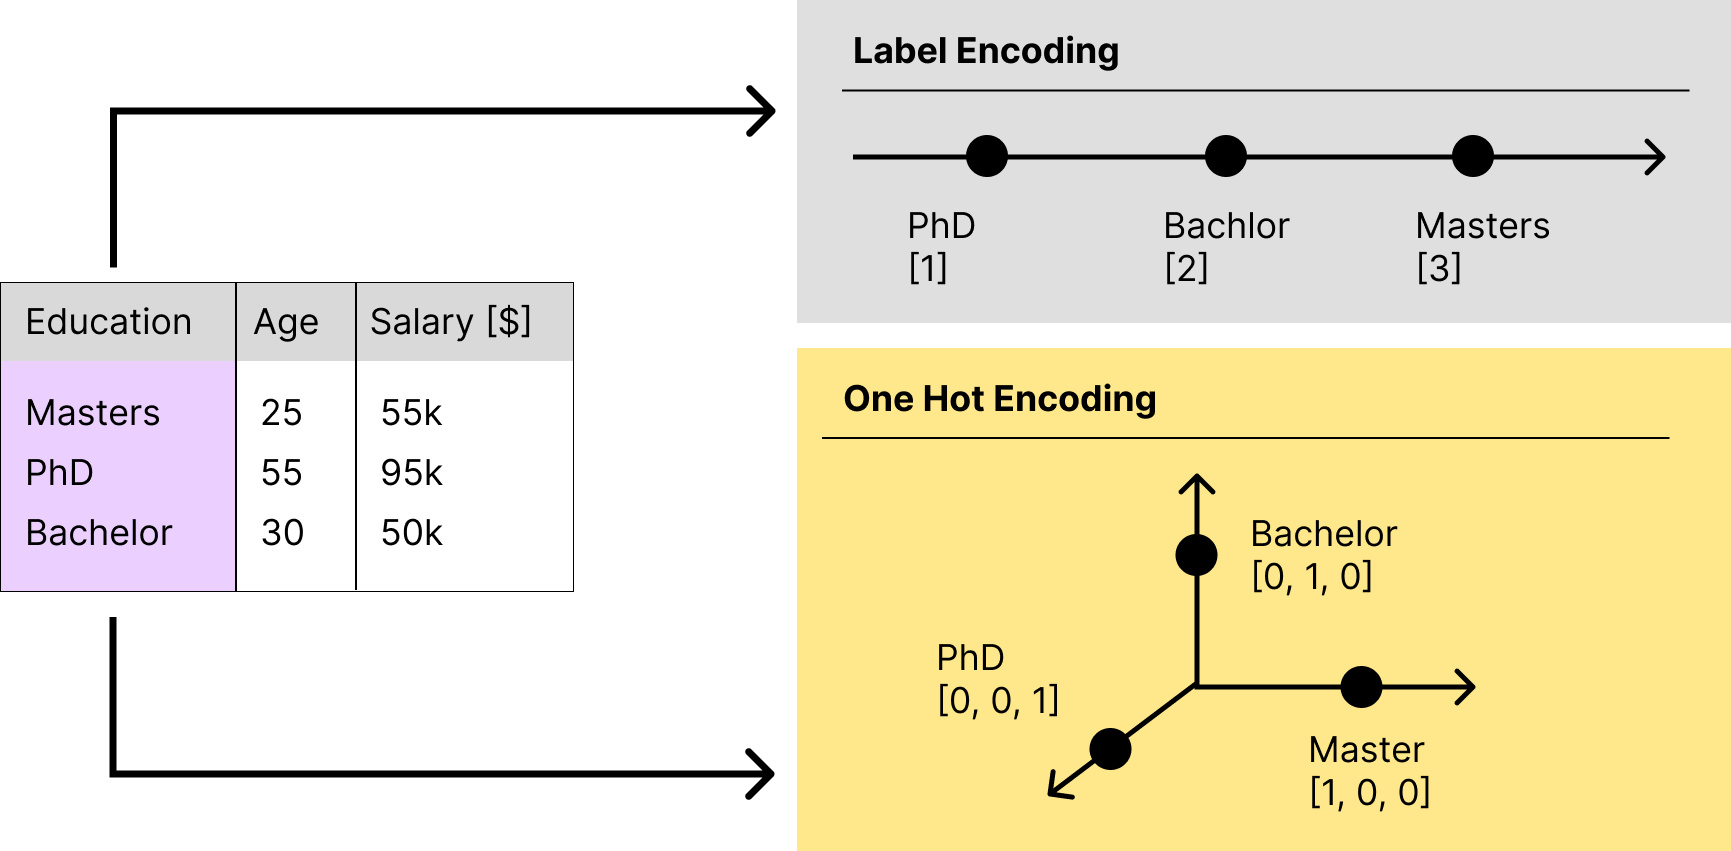

In [7]:
from IPython.display import Image, display
display(Image(filename="images/rwpc_0503.png", width=500, height=500))

# Embeddings and Semantic Meaning in RAG Systems

RAG systems rely on **embedding models** that capture the **semantic meaning of text**.  
This allows the system to retrieve information based on **conceptual relationships**, rather than simply matching exact keywords.

Instead of treating words as independent labels, embedding models represent words as **vectors in a high-dimensional space** where similar concepts are positioned close to each other.

---

# Example: Royal Titles in Vector Space

To understand this concept, consider an example using **royal titles** such as:

- Queen  
- King  
- Princess  
- Prince  

Instead of assigning **random numbers**, embeddings map these words into vectors where **each dimension represents a meaningful characteristic**.

For example, the vector space might use three dimensions:

1. **Age** – Older vs younger royal members  
2. **Gender** – Male vs female  
3. **Royal Status** – Position in the royal hierarchy

---

# Vector Representations

Using these dimensions, words can be represented as vectors.

Example:

| Word | Vector Representation | Meaning |
|-----|------|------|
| King | [0.8, 0, 1] | Older, male, high royal status |
| Queen | [0.8, 1, 1] | Older, female, high royal status |
| Prince | [0.3, 0, 0.5] | Younger, male, lower status |
| Princess | [0.3, 1, 0.5] | Younger, female, lower status |

Each number represents a **specific characteristic**:

- First value → Age  
- Second value → Gender  
- Third value → Royal hierarchy level

This allows embeddings to capture **meaningful relationships between words**.

---

# Vector Arithmetic in Embeddings

One powerful feature of embeddings is that we can perform **vector arithmetic**.

Vector operations are performed **dimension by dimension**.

Example:

```
King - Man + Woman ≈ Queen
```

This works because embeddings encode **semantic properties**.

Example calculation:

```
King      = [0.8, 0, 1]
Man       = [0.6, 0, 0]
Woman     = [0.6, 1, 0]

King - Man + Woman
= [0.8,0,1] - [0.6,0,0] + [0.6,1,0]
= [0.8,1,1]
≈ Queen
```

This demonstrates how embedding models capture **semantic structure in vector space**.

---

# Why This Matters for RAG

Because embeddings preserve semantic relationships:

- Similar concepts are **closer in vector space**
- Related topics cluster together
- Queries can retrieve relevant information even when the **exact words differ**

For example:

Query:  
*Who is the female ruler of a kingdom?*

Retrieved concept:  
**Queen**

Even though the exact word "queen" was not used in the query, embeddings can still retrieve it based on **semantic similarity**.

This capability is what makes embeddings a **core component of Retrieval-Augmented Generation (RAG) systems**.

### Calculating the Distance Between Embeddings

# Cosine Similarity

Cosine similarity measures how similar two vectors are by comparing their **direction** rather than their magnitude.

It computes the **cosine of the angle between two vectors** in high-dimensional space.

- If vectors point in the **same direction** → similarity = **1**
- If vectors are **orthogonal (unrelated)** → similarity = **0**
- If vectors point in **opposite directions** → similarity = **-1**

## Cosine Similarity Formula

<img src="images/cosine.png" width="500">

Where:

- \(A \cdot B\) = **dot product** of vectors  
- \(||A||\) = **magnitude (norm)** of vector A  
- \(||B||\) = **magnitude (norm)** of vector B  

---

# Dot Product

The dot product measures how aligned two vectors are.

It multiplies corresponding elements of the vectors and then sums them.

## Dot Product Formula

<img src="images/cosine1.png" width="500">
Where:

- \(A_i\) = element of vector A  
- \(B_i\) = element of vector B  
- \(n\) = number of dimensions (e.g., **1536 for many embeddings**)

### Example

If:

\[
A = [1,2,3]
\]

\[
B = [4,5,6]
\]

Then:

\[
A \cdot B = (1 \times 4) + (2 \times 5) + (3 \times 6)
\]

\[
= 4 + 10 + 18 = 32
\]

---

# Vector Magnitude (Norm)

The magnitude of a vector represents the **length of the vector** in space.

It is calculated by squaring each element, summing them, and taking the square root.

## Vector Magnitude Formula

<img src="images/cosine2.png" width="500">

### Example

If:

\[
A = [3,4]
\]

Then:

\[
||A|| = \sqrt{3^2 + 4^2}
\]

\[
= \sqrt{9 + 16}
\]

\[
= \sqrt{25} = 5
\]

---

# Why Normalization Matters

Vector magnitude is used to **normalize vectors** so that similarity depends on **direction rather than length**.

This ensures that cosine similarity measures **semantic similarity instead of vector size**.

---

# How These Three Work Together

1. **Dot Product** measures alignment between vectors.
2. **Vector Magnitude** calculates vector length.
3. **Cosine Similarity** divides alignment by vector lengths.

<img src="images/cosine2.png" width="500">

\[
\text{Cosine Similarity} =
\frac{\text{Dot Product}}{\text{Vector Lengths}}
\]

This produces a similarity score between **-1 and 1**.

---

# Why This Is Important in AI

These formulas are fundamental to:

- **Embeddings**
- **Semantic Search**
- **Vector Databases**
- **FAISS Similarity Search**
- **Retrieval-Augmented Generation (RAG)**

Example workflow:


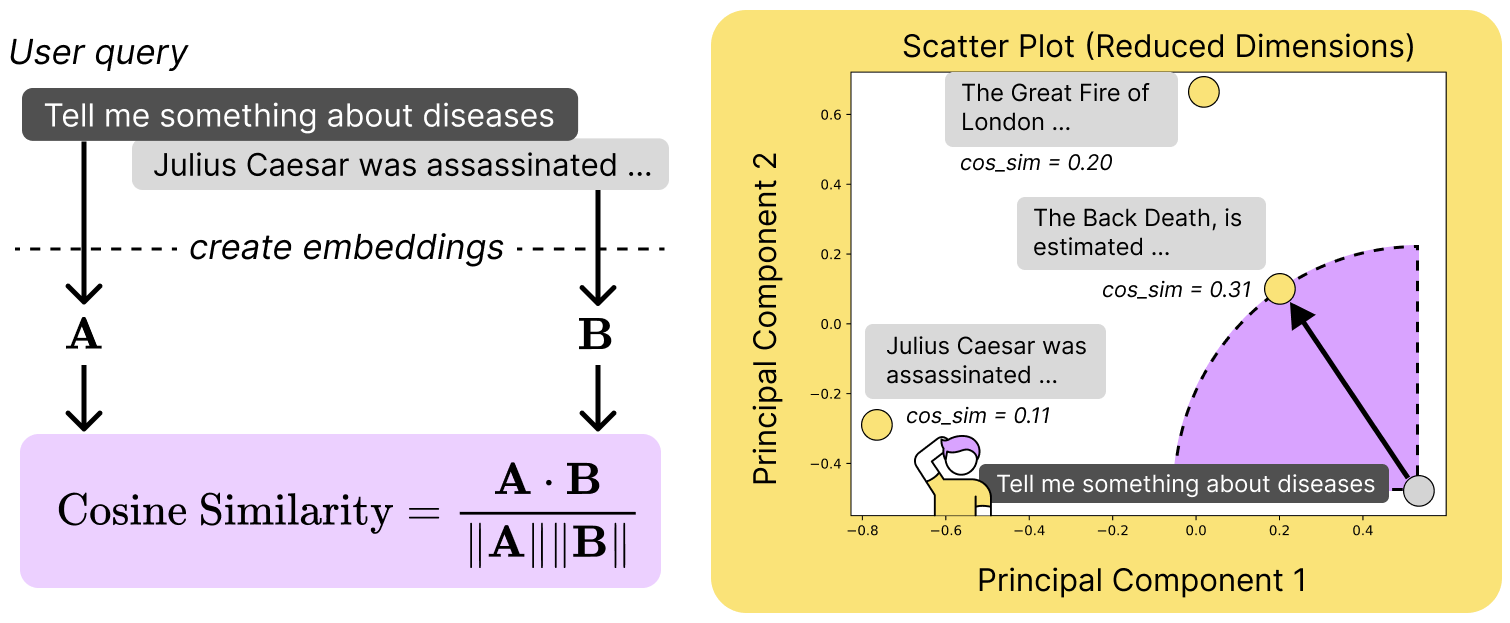

In [11]:
from IPython.display import Image, display
display(Image(filename="images/rwpc_0509.png", width=500, height=500))

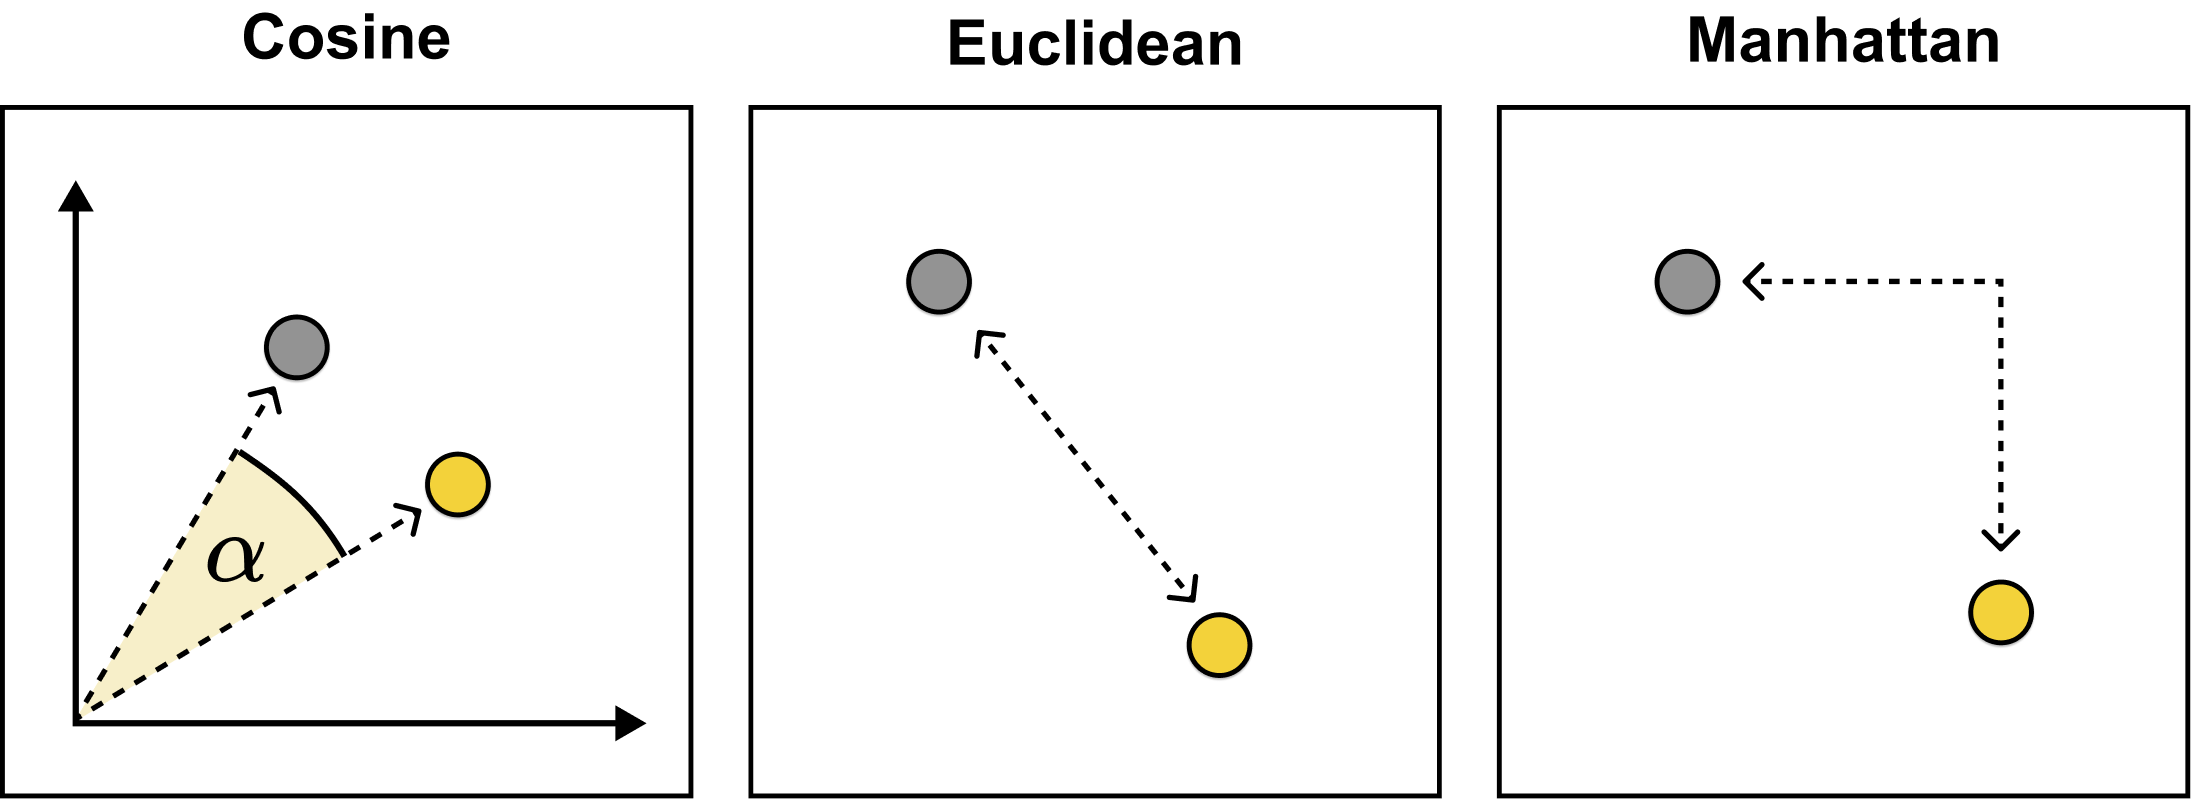

In [12]:
display(Image(filename="images/rwpc_0510.png", width=500, height=500))

# Cosine Similarity in RAG Systems

Cosine similarity measures the **angle between two vectors** rather than their absolute distance.

In embedding-based systems like **Retrieval-Augmented Generation (RAG)**, cosine similarity is the **most commonly used similarity metric** because it focuses on **semantic direction** rather than vector magnitude.

This means that two pieces of text with similar meaning will have vectors pointing in **similar directions**, resulting in a **high cosine similarity score**.

---

# Why Cosine Similarity Works Well for RAG

User queries are typically **short**, while retrieved documents are often **much longer**.

Example:

Query:
```
reset password
```

Document:
```
To reset your password, go to the account settings page and follow the password recovery instructions.
```

Although the document vector will have a **larger magnitude**, both vectors point in the **same semantic direction**.

Cosine similarity correctly identifies them as **highly related**, even though their lengths differ.

Without normalization, longer documents might rank higher **simply due to magnitude**, not semantic relevance.

---

# Cosine Similarity Formula

Cosine similarity is defined as:

<img src="images/cosine.png" width="500">


# Dot Product

<img src="images/cosine1.png" width="500">

The dot product between two vectors is:

\[
A \cdot B = \sum_{i=1}^{n} A_i B_i
\]

Where:

- \(n\) = number of dimensions (e.g., 1536 for many embeddings)

---

# Vector Magnitude (Norm)
<img src="images/cosine2.png" width="500">

The magnitude of a vector is:

\[
||A|| = \sqrt{\sum_{i=1}^{n} A_i^2}
\]

This normalization step ensures similarity depends on **direction rather than length**.

---

# Cosine Similarity Range

| Value | Meaning |
|------|------|
| 1 | Identical semantic direction |
| 0 | Unrelated vectors |
| -1 | Opposite meaning |

In practice, embeddings for natural language usually fall between:

```
0.3 – 0.9
```

for semantically related text.

---

# Example Calculation

Assume two simplified embedding vectors:

```
A = [1, 2, 3]
B = [2, 4, 6]
```

Dot product:

```
A · B = (1×2) + (2×4) + (3×6) = 28
```

Magnitudes:

```
||A|| = √(1² + 2² + 3²) = √14
||B|| = √(2² + 4² + 6²) = √56
```

Cosine similarity:

```
cos(A,B) = 28 / (√14 × √56)
```

Result ≈ **1**, meaning the vectors point in the **same direction**.

---

# Other Distance Metrics

Although cosine similarity is the standard metric for embeddings, other metrics exist.

---

# Euclidean Distance

Euclidean distance measures the **straight-line distance between vectors**.

Formula:
<img src="images/Euclidean.png" width="500">

\[
d(A,B) = \sqrt{\sum_{i=1}^{n}(A_i - B_i)^2}
\]

Characteristics:

- Sensitive to vector magnitude
- Useful when **vector length carries semantic meaning**

However, modern transformer embeddings rarely encode meaning in magnitude.

---

# Dot Product Similarity

Dot product similarity:

\[
A \cdot B
\]

Advantages:

- Faster computation
- Works well if vectors are **normalized beforehand**

In production systems, vectors are often **pre-normalized during indexing**, allowing dot product to behave like cosine similarity.

---

# Manhattan Distance

Manhattan distance measures the **sum of absolute differences**.

Formula:

<img src="images/Manhattan.png" width="500">

\[
d(A,B) = \sum_{i=1}^{n} |A_i - B_i|
\]

Characteristics:

- Works well with **sparse high-dimensional vectors**
- Less common with **dense transformer embeddings**

---

# Comparison of Similarity Metrics

| Metric | Strength | Weakness |
|------|------|------|
| Cosine Similarity | Best for semantic similarity | Slightly slower than dot product |
| Euclidean Distance | Good when magnitude matters | Sensitive to document length |
| Dot Product | Very fast in production | Requires normalized vectors |
| Manhattan Distance | Efficient for sparse vectors | Rarely used for embeddings |

---

# Best Practice for RAG Systems

For modern **transformer-based embeddings**:

- Use **cosine similarity** as the default retrieval metric
- Normalize vectors during indexing
- Optionally use **dot product for faster computation**

In practice:

**Over 95% of RAG systems use cosine similarity** for semantic retrieval.

---

# Key Takeaway

Cosine similarity is ideal for RAG systems because:

- It focuses on **semantic direction**
- It handles **documents with different lengths**
- It works well with **transformer-based embeddings**

This makes cosine similarity the **standard similarity metric for semantic search and RAG pipelines**.

In [14]:
# Import required libraries
import numpy as np                    # Used for numerical operations
from numpy.linalg import norm        # Used for vector magnitude calculations (often for cosine similarity)
import pandas as pd                  # Used for creating and manipulating data tables (DataFrames)
import os                            # Used for interacting with environment variables
from openai import OpenAI            # OpenAI client library for accessing embedding models

# Define a list of historical text chunks
# These represent small pieces of information that could come from a document dataset
text_chunks = [
    "The Great Fire of London in 1666 destroyed over 13,000 houses.",
    "Julius Caesar was assassinated on the Ides of March (March 15) in 44 BCE.",
    "The Black Death is estimated to have killed nearly one-third of the population.",
]

# Define the user's query/question
# In a RAG system this question will be embedded and compared to document embeddings
users_question = "Tell me something interesting about diseases in history"

# Create a pandas DataFrame to store text chunks
# This makes it easier to attach embeddings and perform analysis
embeddings_df = pd.DataFrame(text_chunks, columns=["text_chunk"])

# Initialize the OpenAI client
# The API key is automatically read from the environment variable OPENAI_API_KEY
client = OpenAI()

# Create an empty list to store embeddings (optional helper list)
embeddings = []

# Function to generate embeddings for a given text chunk
def create_embeddings(text_chunk, client):

    # Call the OpenAI embeddings API
    # "text-embedding-3-small" converts text into a numerical vector
    embedding = (
        client.embeddings.create(
            input=[text_chunk],                # Text that needs to be converted to a vector
            model="text-embedding-3-small"     # Embedding model used
        )
        .data[0]                               # Access the first result
        .embedding                             # Extract the actual embedding vector
    )

    # Return the embedding vector
    return embedding


# Apply the embedding function to every text chunk in the DataFrame
# This creates a new column called "embedding" containing vector representations
embeddings_df["embedding"] = embeddings_df["text_chunk"].apply(
    create_embeddings, client=client
)

# Generate an embedding for the user's question
# This will later be compared with document embeddings to find the most relevant chunk
users_question_embedding = create_embeddings(
    text_chunk=users_question,
    client=client
)

ModuleNotFoundError: No module named 'openai'

In [ ]:
# Create an empty list to store cosine similarity scores
# (Optional here because we store similarity directly in the DataFrame later)
cos_sim = []

# Define a function to calculate cosine similarity between two vectors
def calculate_cosine_similarity(text_chunk_embedding, users_question_embedding):
    
    # Assign the embeddings to variables for easier reading
    A = text_chunk_embedding           # embedding vector of a document/text chunk
    B = users_question_embedding       # embedding vector of the user's question

    # Calculate cosine similarity
    # Formula: cosine_similarity = (A · B) / (||A|| * ||B||)
    # np.dot(A, B) → dot product of the two vectors
    # norm(A) and norm(B) → magnitude (length) of each vector
    cosine = np.dot(A, B) / (norm(A) * norm(B))

    # Return the similarity score
    return cosine


# Apply the cosine similarity function to each embedding in the DataFrame
# The function compares every document embedding with the user's question embedding
embeddings_df["similarity"] = embeddings_df["embedding"].apply(
    calculate_cosine_similarity,
    users_question_embedding=users_question_embedding
)

# Print the updated DataFrame to see similarity scores
print(embeddings_df)

In [ ]:
# Import the cosine similarity utility from sentence_transformers
# This function provides an easy way to calculate cosine similarity between vectors
from sentence_transformers.util import cos_sim

# Convert the embedding column from the DataFrame into a list
# Each element in this list is an embedding vector representing a document
document_embeddings = embeddings_df["embedding"].tolist()

# Store the query embedding
# (Note: normally this should be the embedding of the user's question)
query_embedding = embeddings_df["embedding"].tolist()

# Loop through each document embedding
for document_embedding in document_embeddings:

    # Compute cosine similarity between the current document embedding
    # and the query embedding
    # cos_sim returns a similarity score showing how close the meanings are
    scores = cos_sim(document_embedding, query_embedding)

# Print the similarity scores
scores

tensor([[0.3404, 0.2003, 1.0000]])

## Visualizing Semantic Relationships Between Text Chunks Using Dimensionality Reduction Techniques

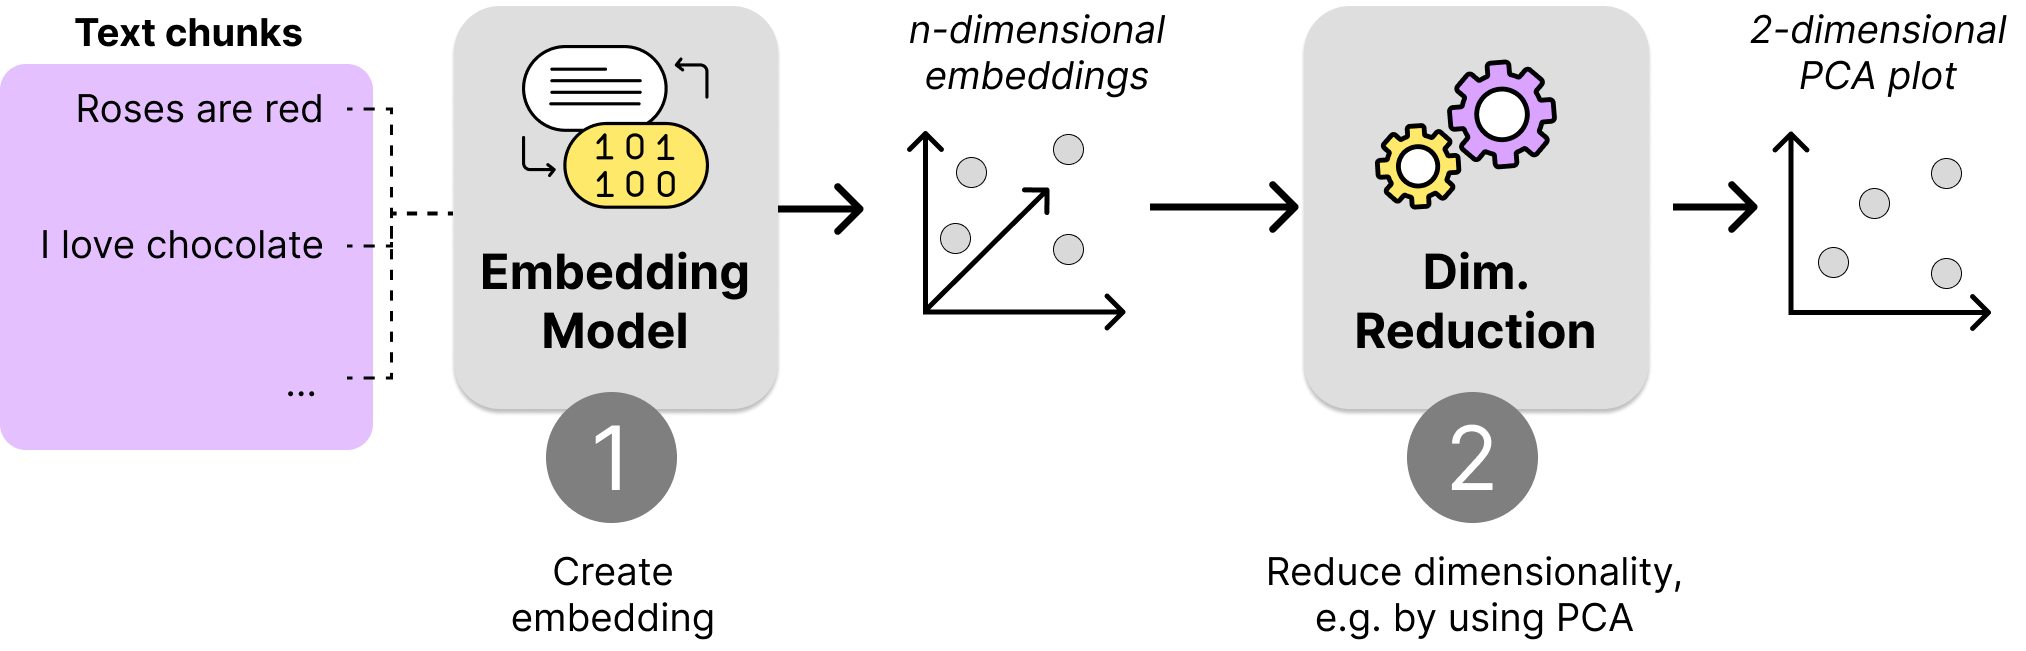

In [8]:
from IPython.display import Image, display
display(Image(filename="images/rwpc_0506.png", width=500, height=500))

### How to reduce the dimensionality of embeddings to be able to plot them

In [ ]:
# Import required libraries
import os                                  # Used to access environment variables such as API keys
import pandas as pd                        # Used to store embeddings in a structured DataFrame
import matplotlib.pyplot as plt            # Used for visualization
from sklearn.decomposition import PCA      # Used for dimensionality reduction (high-dim vectors → 2D)
from openai import OpenAI                  # OpenAI client for generating embeddings

# Define a list of text chunks
# Each sentence represents a small piece of text that we want to convert into embeddings
text_chunks = [
    "The sky is blue.",
    "The sun is shining.",
    "I love chocolate.",
    "Ice cream is delicious.",
    "Roses are red.",
    "Violets are blue.",
]

# Initialize the OpenAI client
# The API key should already be stored in the environment variable OPENAI_API_KEY
client = OpenAI()

# Create an empty list to store embedding vectors
embeddings = []

# Loop through each text chunk and generate embeddings
for text_chunk in text_chunks:

    # Call the OpenAI embeddings API
    # The model converts the text into a numerical vector representation
    response = client.embeddings.create(
        input=[text_chunk],                 # Text that needs to be converted into a vector
        model="text-embedding-3-small"      # Embedding model used
    )

    # Extract the embedding vector from the response
    # response.data[0].embedding contains the numerical representation of the text
    embeddings.append(response.data[0].embedding)


# Convert embeddings into a pandas DataFrame
# Each row corresponds to one sentence (text chunk)
# Each column corresponds to one dimension of the embedding vector
embeddings_df = pd.DataFrame(
    embeddings,
    columns=[f"dim_{i}" for i in range(len(embeddings[0]))]  # Create column names like dim_0, dim_1, ...
)

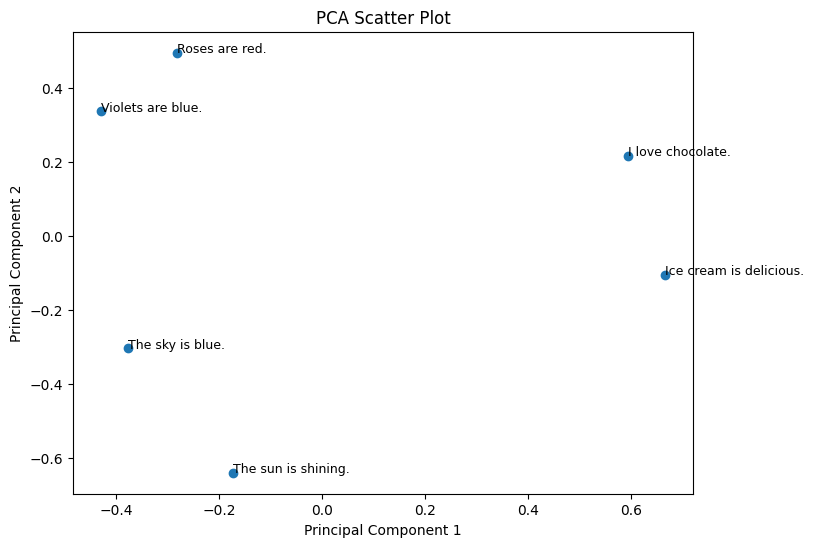

In [ ]:
# Perform PCA (Principal Component Analysis)
# n_components=2 reduces the high-dimensional embeddings into 2 dimensions
# This allows us to visualize the embeddings on a 2D plot
pca = PCA(n_components=2)

# Fit PCA on the embeddings DataFrame and transform the data
# This converts the high-dimensional embedding vectors into two principal components
df_reduced = pca.fit_transform(embeddings_df)

# Convert the PCA result into a pandas DataFrame
# PC1 = first principal component
# PC2 = second principal component
df_reduced = pd.DataFrame(df_reduced, columns=["PC1", "PC2"])

# Add the original text chunks to the DataFrame
# This will help us label each point in the visualization
df_reduced["text"] = text_chunks


# Create a scatter plot figure
# figsize controls the size of the plot
plt.figure(figsize=(8, 6))

# Plot the PCA-reduced points on a 2D scatter plot
# Each point represents one text chunk
plt.scatter(df_reduced["PC1"], df_reduced["PC2"])


# Add labels to each point in the plot
# This helps identify which sentence corresponds to which point
for i, label in enumerate(df_reduced["text"]):

    # Place text labels at the corresponding PCA coordinates
    plt.text(df_reduced["PC1"][i], df_reduced["PC2"][i], label, fontsize=9)


# Label the X-axis
plt.xlabel("Principal Component 1")

# Label the Y-axis
plt.ylabel("Principal Component 2")

# Add a title to the plot
plt.title("PCA Scatter Plot")


# Save the plot as an SVG file
# SVG format keeps the image high quality and scalable
plt.savefig("../principal_component_plot.svg", format="svg")

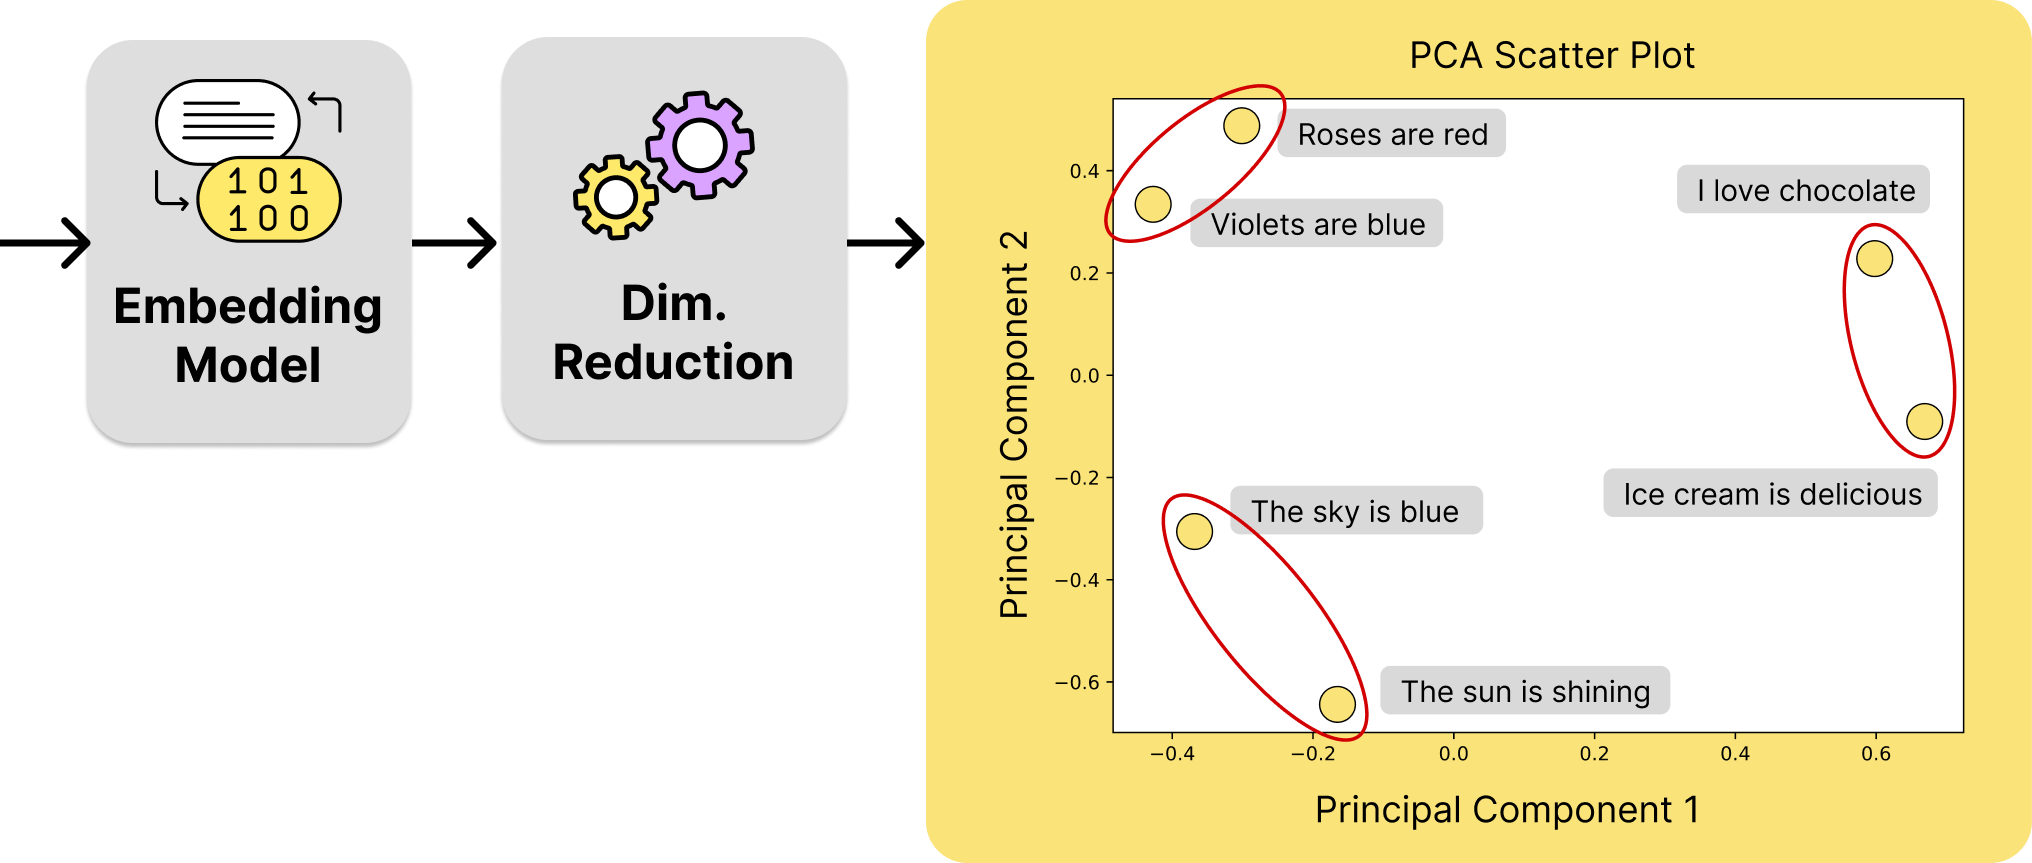

In [9]:
from IPython.display import Image, display
display(Image(filename="images/rwpc_0507.png", width=500, height=500))

# Dimensionality Reduction for Embedding Visualization

Embedding vectors often contain **hundreds or thousands of dimensions** (for example, 1,536).  
Visualizing such high-dimensional data directly is not possible, so we use **dimensionality reduction techniques** to project these vectors into a **lower-dimensional space**, typically **2D or 3D**.

The goal is to preserve the **relative distances between points**, so that text chunks that are semantically similar in the original high-dimensional space remain **close together after projection**.

---

# PCA (Principal Component Analysis)

**Principal Component Analysis (PCA)** is a commonly used dimensionality reduction method.

PCA works by:

1. Identifying the directions in the data with the **maximum variance**
2. Creating new axes called **principal components**
3. Projecting the high-dimensional vectors onto these new axes

When reducing **1,536 dimensions to 2**, PCA keeps the two directions that capture the **most information about the data distribution**.

As a result:

- Text chunks with **similar meaning** often remain **close together**
- Unrelated content tends to appear **far apart**

---

# Why Visualization Is Useful During Development

Embedding visualization is extremely useful when **building and validating RAG systems**.

During development, plotting embeddings can help verify that:

- **Semantically similar documents cluster together**
- **Different topics form separate clusters**

Example:

- Legal documents may cluster together
- Marketing materials may form another cluster
- Technical documentation may appear in a separate region

This confirms that the **embedding model is capturing meaningful semantic relationships**.

Visualization is also useful when presenting systems to **stakeholders or regulators**, especially in industries like:

- Finance  
- Healthcare  
- Legal technology  

Showing clustering behavior makes the **retrieval logic more transparent and understandable during demos**.

---

# Limitations of 2D Visualization

2D plots should **not be used in production diagnostics**.

Reducing **1,536 dimensions to just 2** inevitably loses a large amount of information.

Because of this:

- Some relationships between vectors cannot be shown
- Clusters may appear closer or farther apart than they actually are
- Important high-dimensional structure may disappear

Instead, production systems should be evaluated using **retrieval performance metrics**, such as:

- **Precision@k**
- **Recall@k**
- **Mean Reciprocal Rank (MRR)**
- **Hit Rate**

These metrics measure how well the system retrieves **relevant documents for user queries**.

---

# Trade-offs Between PCA, t-SNE, and UMAP

Several dimensionality reduction techniques are available, each with different strengths.

| Method | Advantages | Limitations |
|------|------|------|
| **PCA** | Fast, deterministic, easy to compute | May miss non-linear relationships |
| **t-SNE** | Preserves local clusters very well | Slow for large datasets, sensitive to parameters |
| **UMAP** | Preserves both local and global structure | Requires parameter tuning |

**PCA**

- Linear dimensionality reduction
- Very fast and stable
- Good for **initial exploration**

**t-SNE**

- Excellent for **visualizing clusters**
- Captures **local relationships**
- Computationally expensive

**UMAP**

- Often better than t-SNE for **large datasets**
- Preserves both **local and global structure**
- Faster than t-SNE in many cases

---

# Key Takeaway

Dimensionality reduction helps us **visualize and understand embedding spaces** during development.

However:

- Use **PCA or t-SNE for exploration and debugging**
- Use **retrieval evaluation metrics in production**

Visualization helps ensure that the embedding model is **learning meaningful semantic relationships**, which is critical for building effective **RAG systems**.

# Dimensionality Reduction for Embedding Visualization

Embedding models often produce **high-dimensional vectors** (for example, 1,536 dimensions).  
These vectors encode semantic meaning, but such high-dimensional spaces are difficult to interpret visually.

To analyze embedding behavior, we apply **dimensionality reduction**, which projects high-dimensional vectors into a **lower-dimensional space (2D or 3D)** while preserving meaningful relationships between points.

The goal is to maintain **relative distances**, so that text chunks that are semantically similar remain **close together** after projection.

---

# Core Idea of Dimensionality Reduction

Given a dataset of embeddings:

\[
X = [x_1, x_2, ..., x_n], \quad x_i \in \mathbb{R}^{1536}
\]

Each embedding vector has **1536 dimensions**.

Dimensionality reduction transforms the dataset into:

\[
Z = [z_1, z_2, ..., z_n], \quad z_i \in \mathbb{R}^{2}
\]

Where:

- Original space → **1536D**
- Reduced space → **2D**

The transformation attempts to **preserve the structure of the data**.

---

# PCA (Principal Component Analysis)

**Principal Component Analysis (PCA)** is a linear dimensionality reduction technique that finds the **directions of maximum variance** in the dataset.

These directions are called **principal components**.

### PCA Objective

PCA finds orthogonal vectors that maximize variance:

\[
\text{maximize } Var(Xw)
\]

subject to:

\[
||w|| = 1
\]

Where:

- \(X\) = data matrix
- \(w\) = projection direction (principal component)

---

# PCA Mathematical Steps

1. Standardize the dataset

\[
X_{standardized} = \frac{X - \mu}{\sigma}
\]

2. Compute the covariance matrix

\[
C = \frac{1}{n-1}X^TX
\]

3. Perform eigen decomposition

\[
Cv = \lambda v
\]

Where:

- \(v\) = eigenvectors (principal components)
- \(\lambda\) = eigenvalues (variance explained)

4. Select top **k eigenvectors**

For visualization:

\[
k = 2
\]

5. Project the data

\[
Z = XW
\]

Where:

- \(W\) = matrix of top principal components

---

# Why PCA Works for Embeddings

Embedding vectors contain **latent semantic information**.

PCA identifies the directions where the **most meaningful variation occurs**, allowing us to visualize semantic clusters.

Example clusters in RAG datasets:

- Legal documents
- Marketing materials
- Product documentation
- Financial reports

Semantically related documents will appear **close together in the 2D plot**.

---

# Distance Metrics in Embedding Space

Embeddings rely on **vector similarity** to measure meaning.

### Euclidean Distance

\[
d(x,y) = \sqrt{\sum_{i=1}^{n}(x_i - y_i)^2}
\]

Measures straight-line distance between vectors.

---

### Cosine Similarity (Most Common for Embeddings)

\[
\text{cosine similarity} =
\frac{x \cdot y}{||x|| \; ||y||}
\]

Where:

- \(x \cdot y\) = dot product
- \(||x||\) = vector magnitude

Range:

- **1** → identical meaning
- **0** → unrelated
- **-1** → opposite meaning

RAG systems usually rely on **cosine similarity** for retrieval.

---

# Why Visualization Is Useful During Development

Embedding visualization helps validate whether the system is learning **meaningful semantic representations**.

During development you can verify that:

- Similar topics cluster together
- Unrelated content separates clearly
- Embedding quality is sufficient for retrieval

Example clustering:

| Cluster | Content Type |
|------|------|
| Cluster 1 | Legal documents |
| Cluster 2 | Marketing materials |
| Cluster 3 | Technical documentation |

This confirms the embedding model captures **semantic structure**.

Visualization is also valuable in **regulated industries**, because it helps stakeholders understand **how retrieval works**.

---

# Limitations of 2D Visualization

2D visualizations simplify **1,536 dimensions into just 2**, which introduces information loss.

Important limitations:

- Some relationships disappear
- Cluster distances may be distorted
- Overlapping clusters may appear separated

Because of this, **2D plots should not be used in production diagnostics**.

Instead evaluate RAG systems using retrieval metrics.

---

# Production Evaluation Metrics

In production systems, measure retrieval quality using metrics such as:

### Precision@k

\[
Precision@k = \frac{\text{Relevant documents retrieved}}{k}
\]

---

### Recall@k

\[
Recall@k = \frac{\text{Relevant documents retrieved}}{\text{Total relevant documents}}
\]

---

### Mean Reciprocal Rank (MRR)

\[
MRR = \frac{1}{N} \sum_{i=1}^{N} \frac{1}{rank_i}
\]

Measures how early the correct result appears in retrieval.

---

# PCA vs t-SNE vs UMAP

Different dimensionality reduction techniques preserve different structures.

| Method | Strengths | Weaknesses |
|------|------|------|
| PCA | Fast, deterministic, scalable | Captures only linear relationships |
| t-SNE | Excellent local clustering | Slow, sensitive to parameters |
| UMAP | Preserves local and global structure | Requires tuning |

### When to Use Each

**PCA**

- Fast exploratory analysis
- Large datasets
- Baseline visualization

**t-SNE**

- Small datasets
- Cluster exploration
- Visual storytelling

**UMAP**

- Large datasets
- Modern embedding visualization
- Better global structure preservation

---

# Key Takeaway

Dimensionality reduction helps us **understand embedding spaces** during development.

Use visualization to:

- Validate semantic clustering
- Detect embedding issues
- Demonstrate system behavior

But remember:

- Visualization is for **development and debugging**
- Production systems should rely on **retrieval performance metrics**
- Embedding similarity is typically measured using **cosine similarity**

Dimensionality reduction therefore acts as a **diagnostic tool** that helps developers verify that their **RAG pipeline retrieves semantically meaningful content**.

## Generating Embeddings for Images and Text Using CLIP

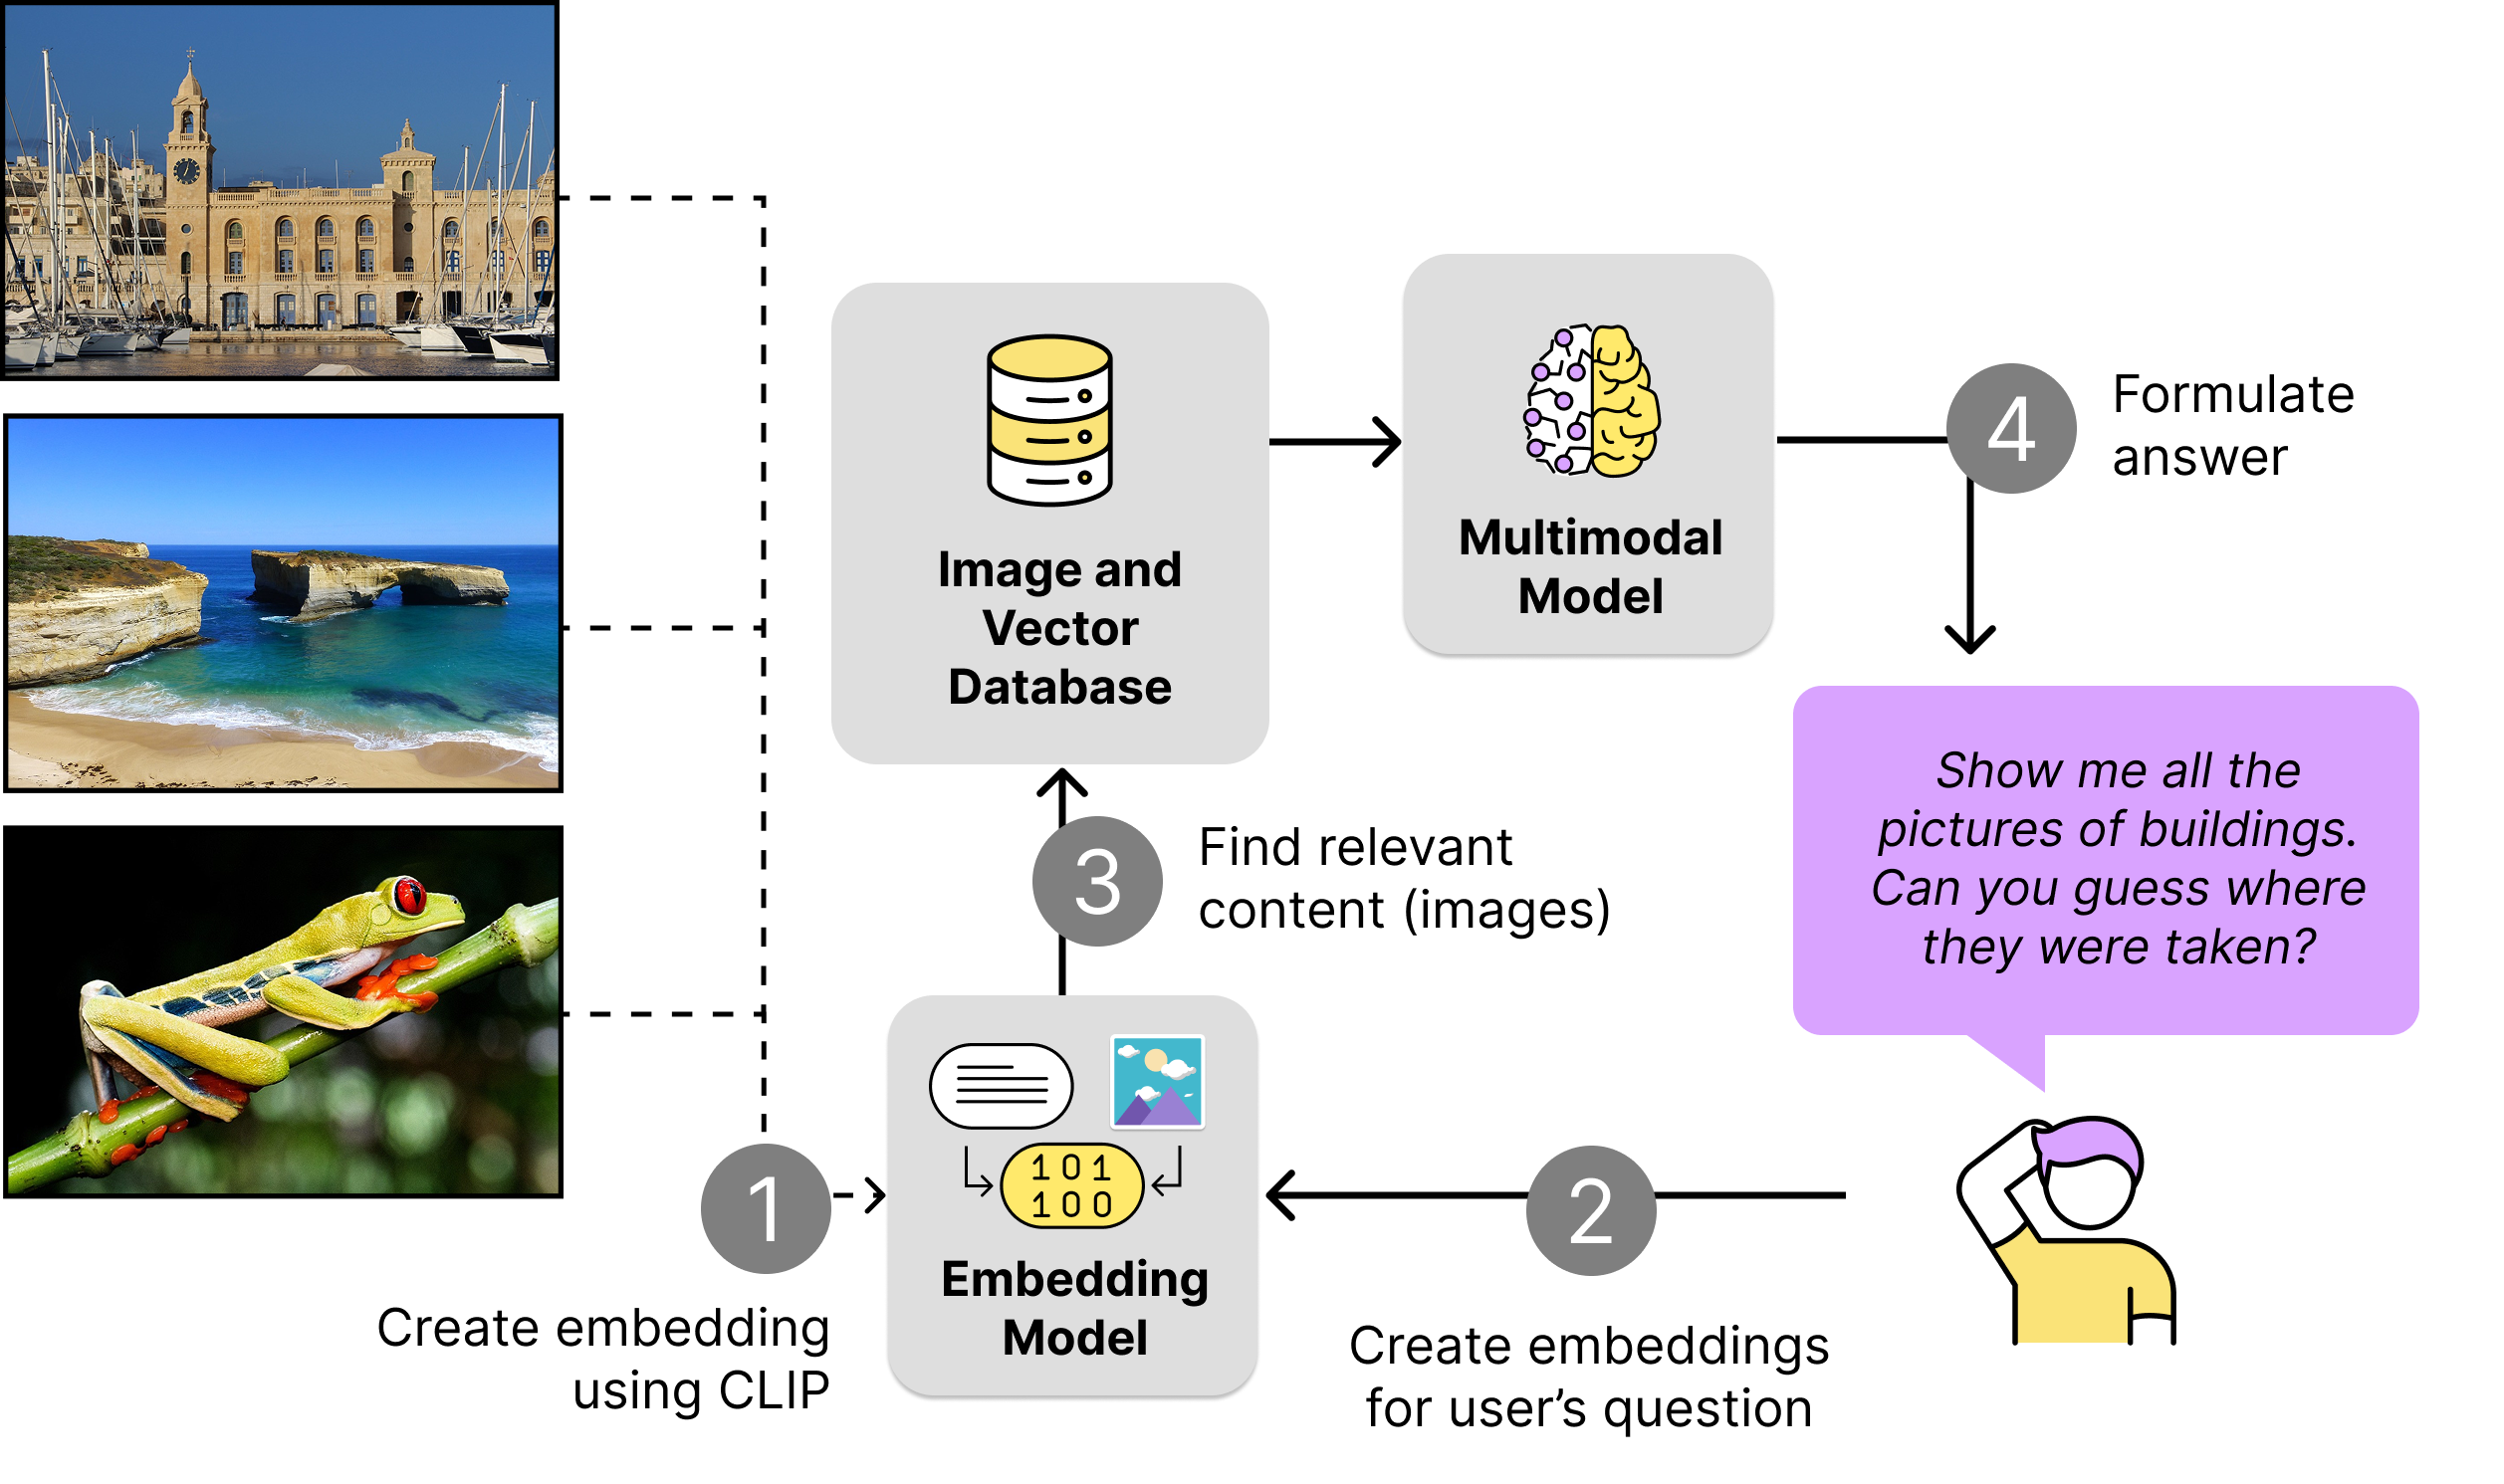

In [16]:
from IPython.display import Image, display
display(Image(filename="images/rwpc_0511.png", width=500, height=500))

### Problem
You want to classify images or perform cross-modal matching between images and text using embeddings.

### Solution
Use Contrastive Language-Image Pre-training (CLIP) to generate embeddings for both images and text, enabling cross-modal matching and classification.

# Multimodal Retrieval with CLIP

Generate embeddings for **all images and text** that you want to add to the vector store.

Both images and text are converted into **numerical embedding vectors** using a model such as **CLIP**, which maps different modalities into a **shared embedding space**. This allows the system to compare images and text using the same similarity metric.

---

## Query Processing

When a user asks a question, use **CLIP** to generate an embedding for the query.

Example query:

```
How do I reset my password?
```

The query is converted into a **vector representation** that captures its semantic meaning.

---

## Similarity Search

Compare the newly generated **query embedding vector** with the embedding vectors stored in the **vector store**.

The system calculates similarity between vectors using a metric such as **cosine similarity**:

\[
\text{similarity}(A,B) =
\frac{A \cdot B}{||A|| \; ||B||}
\]

The most similar vectors represent **content that is semantically related to the user query**.

---

## Retrieve Relevant Content

The vector store returns the **top-k most similar results**, which may include:

- Relevant images  
- Related text chunks  
- Diagrams or visual documentation

These retrieved items form the **context for answering the user’s question**.

---

## Multimodal Reasoning

Finally, send the retrieved **images and text** to a **multimodal model** that can interpret both modalities simultaneously.

The multimodal model analyzes the combined information and generates a **final answer for the user’s question**.

### How to calculate multimodal embeddings using CLIP

In [ ]:
# Import required libraries
import torch                                 # PyTorch library used for deep learning models
from PIL import Image                        # Used to open and process image files
from transformers import CLIPProcessor, CLIPModel  # Hugging Face classes for loading the CLIP model and preprocessing inputs


# Load the pre-trained CLIP model
# CLIP (Contrastive Language–Image Pretraining) can understand relationships between images and text
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")

# Load the processor associated with the model
# The processor prepares both text and images into the correct format required by the model
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")


# Define text descriptions that we want to compare with the images
descriptions = ["A photo of a cat", "A photo of a dog"]

# Load the images from the dataset directory
# PIL is used to open image files
images = [
    Image.open("../datasets/images/cat.jpg"),
    Image.open("../datasets/images/dog.jpg"),
]


# Disable gradient computation
# This improves performance because we are only performing inference (prediction), not training
with torch.no_grad():

    # Process both text and images together
    # The processor converts them into tensors that the CLIP model can understand
    inputs = processor(
        text=descriptions,      # text descriptions
        images=images,          # image inputs
        return_tensors="pt",    # return PyTorch tensors
        padding=True,           # pad sequences to the same length
        truncation=True,        # truncate if input exceeds model limits
    )

    # Pass the processed inputs to the CLIP model
    # The model computes embeddings and similarity scores
    outputs = model(**inputs)


# Extract similarity scores between text and images
# logits_per_text contains the similarity (dot product) between each text description and each image
dot_products_per_text = outputs.logits_per_text


# Convert similarity scores into probabilities
# softmax normalizes the values so that they sum to 1
# This tells us the probability that a text description matches a given image
probabilities = dot_products_per_text.softmax(dim=1)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [ ]:
# Print the full probability matrix
# This shows how likely each text description matches each image
print(probabilities)

# Print the probability that the first image corresponds to the first description
# probabilities[0][0] means:
# Row 0 → first text description ("A photo of a cat")
# Column 0 → first image (cat.jpg)
# .item() converts the PyTorch tensor value into a standard Python number
print("Probability that the first image is a cat:", probabilities[0][0].item())


# Print the probability that the second image corresponds to the second description
# probabilities[1][1] means:
# Row 1 → second text description ("A photo of a dog")
# Column 1 → second image (dog.jpg)
print("Probability that the second image is a dog:", probabilities[1][1].item())

tensor([[9.9995e-01, 5.3789e-05],
        [1.2071e-01, 8.7929e-01]])
Probability that the first image is a cat: 0.9999462366104126
Probability that the second image is a dog: 0.8792927861213684


# CLIP: Connecting Images and Text in a Shared Embedding Space

CLIP (Contrastive Language–Image Pretraining) is a multimodal model trained on **millions of image–text pairs collected from the internet**.  
The model learns to map **both images and text into a shared vector space**, where semantically similar content appears close together.

The key idea is that **content with the same meaning should produce similar vectors**, regardless of whether the input is an image or text.

For example:

- Image: a photo of a dog  
- Text: *"a photo of a dog"*

Both inputs produce **embedding vectors located close to each other in vector space**, because CLIP learned this association during training.

---

# Zero-Shot Classification with CLIP

CLIP enables **zero-shot image classification**, meaning it can classify images **without task-specific training**.

Instead of training a classifier, you simply provide **candidate text descriptions** and CLIP ranks them by similarity to the image.

Example candidate labels:

- "a photo of a dog"
- "a photo of a cat"
- "a photo of a car"

CLIP computes similarity between the **image embedding** and **each text embedding**, then selects the most similar label.

\[
\text{similarity}(image, text) =
\frac{I \cdot T}{||I|| \; ||T||}
\]

Where:

- \(I\) = image embedding  
- \(T\) = text embedding  

This makes CLIP extremely flexible because **adding new categories only requires writing new text prompts**, not retraining the model.

---

# When CLIP Is Useful

CLIP is especially useful when:

### 1. Many Possible Categories Exist

Traditional classifiers require retraining when categories change.  
CLIP allows new categories to be added simply by **writing new text descriptions**.

Example:

Product classification system

```
"a red running shoe"
"a leather office shoe"
"a hiking boot"
```

---

### 2. Labeled Training Data Is Limited

Because CLIP is already pretrained on large datasets, it works well in **low-data environments**.

This is useful when labeled training data is:

- scarce
- expensive
- difficult to collect.

---

### 3. Cross-Modal Retrieval

CLIP works well when **images and text are closely related**, enabling retrieval across modalities.

Example domains:

- Product catalogs
- Scientific papers
- Technical documentation
- Media search systems

Example query:

```
diagram of a neural network
```

The system can retrieve:

- relevant figures
- diagrams
- related images.

---

# CLIP in Retrieval Systems

CLIP enables **cross-modal similarity search**, where:

- Text queries retrieve images
- Image queries retrieve text descriptions

Workflow:

1. Generate embeddings for **images and text**
2. Store embeddings in a **vector database**
3. Convert the user query into an **embedding**
4. Retrieve nearest vectors using **cosine similarity**

This allows the system to find **visually relevant content from textual queries**.

---

# Simpler Approach for Most RAG Systems

For many RAG applications, a **simpler architecture works better**.

Instead of storing image embeddings directly, the system:

1. Uses a **multimodal LLM** (e.g., GPT-5.2, Claude Sonnet 4.5) to generate **text descriptions of images**
2. Converts those descriptions into **text embeddings**
3. Stores the text embeddings in the **vector database**
4. Retrieves relevant descriptions during search
5. Sends the **original image to the LLM only when needed**

Example stored record:

| Image | Generated Description |
|------|------|
| UI screenshot | "Login page showing reset password button" |
| Chart | "Bar chart showing quarterly sales growth" |

---

# Why This Approach Is Often Better

Text embedding models are **highly optimized for semantic search**, which makes them very effective for retrieval.

Advantages:

- Simpler pipeline
- Better semantic matching
- Lower system complexity
- Easier debugging

CLIP’s direct image-text mapping can introduce **additional complexity** that is unnecessary for many RAG systems.

---

# Key Takeaway

CLIP is powerful for **multimodal understanding and cross-modal retrieval**, but it is not always required for RAG.

Two common approaches:

**CLIP-based retrieval**

- Embed images and text directly
- Retrieve across modalities

**Text-description approach (simpler)**

- Convert images to text descriptions
- Use standard text embeddings
- Retrieve descriptions
- Pass images to the LLM only when needed

For many RAG systems, the **text-description pipeline is simpler, more scalable, and easier to maintain**.

## Improving Search Results with a Hybrid Search Approach

## Problem
You want to improve retrieval quality by combining multiple search techniques instead of relying on a single one.

## Solution
Combine BM25-based keyword search with vector similarity search, then merge their rankings using Reciprocal Rank Fusion.

1. A keyword search ranks documents based on exact term matches using BM25.
2. An embedding model generates an embedding for the user’s query.
3. A semantic search ranks documents based on vector similarity.
4. The rankings from both searches are merged into a single ranking.

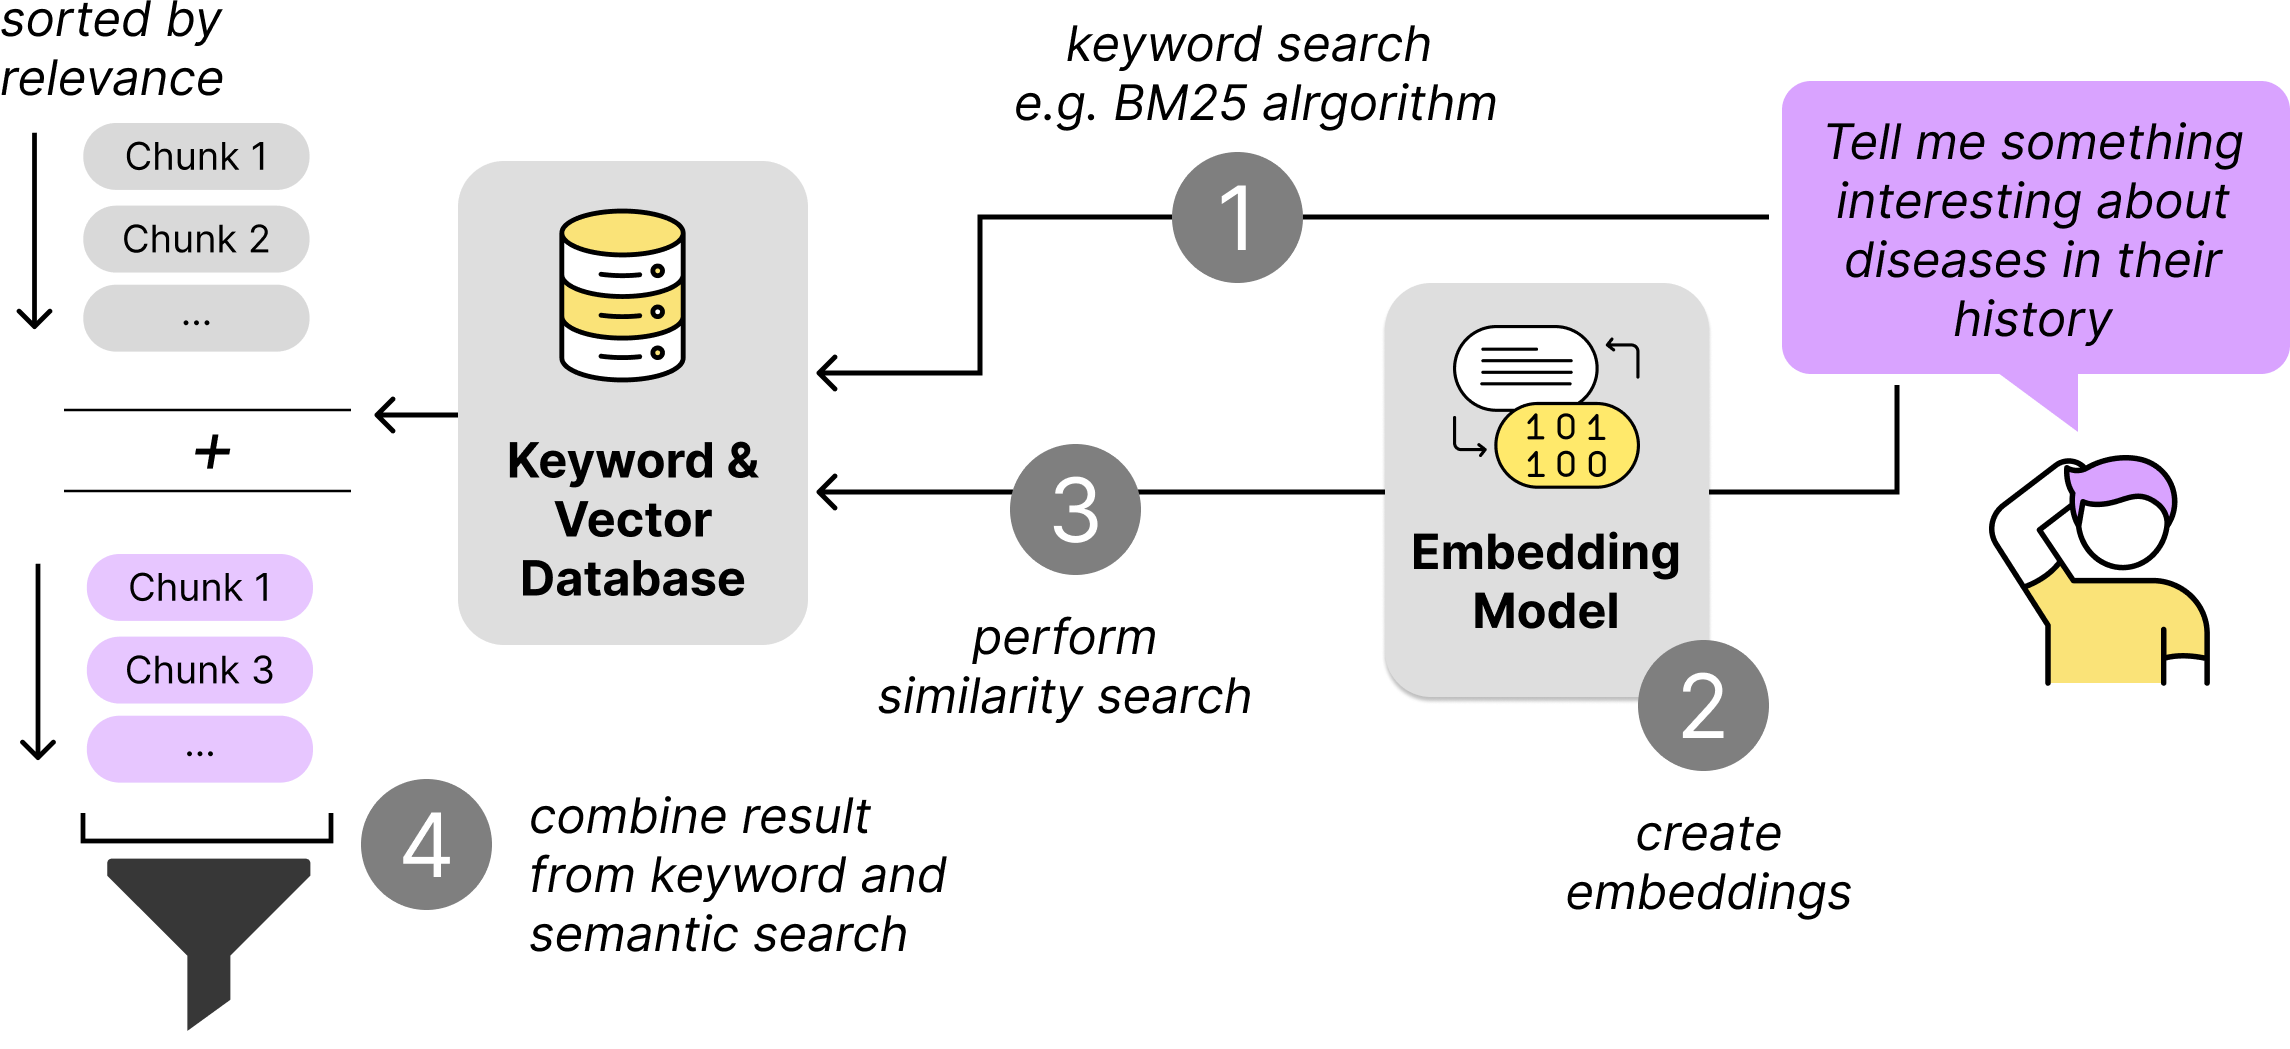

In [18]:
from IPython.display import Image, display
display(Image(filename="images/rwpc_0515.png", width=500, height=500))

- To implement hybrid search, you need three components:
- BM25 for keyword-based ranking, which is especially useful for product names, IDs, codes, and domain-specific terms.
- A text embedding model for semantic similarity search.
- A rank fusion method to merge both rankings into a single result list.

In [19]:
## pip install openai rank-bm25 sentence-transformers pandas

### How to optimize similarity search by combining similarity search and keyword search

In [ ]:
# Import the BM25 ranking algorithm
# BM25 is a popular keyword-based retrieval algorithm used in search engines
from rank_bm25 import BM25Okapi

# Import pandas to help with ranking and organizing results
import pandas as pd


# Define a list of text chunks (documents)
# Each item represents a small document in our dataset
text_chunks = [
    "The Great Fire of London in 1666 destroyed over 13,000 houses.",
    "Julius Caesar was assassinated on the Ides of March (March 15) in 44 BCE.",
    "The Black Death is estimated to have killed nearly one-third of the European population.",
]


# Tokenize each document
# Tokenization means splitting text into individual words
# BM25 requires tokenized input
tokenized_chunks = [chunk.split(" ") for chunk in text_chunks]


# Initialize the BM25 model using the tokenized documents
# The model calculates term frequencies and prepares the ranking structure
bm25 = BM25Okapi(tokenized_chunks)


# Define the user query
user_query = "Tell me something interesting about diseases in history"

# Tokenize the user query in the same way as the documents
tokenized_query = user_query.split(" ")


# Compute BM25 relevance scores
# Each document receives a score based on how well it matches the query keywords
bm25_scores = bm25.get_scores(tokenized_query)


# Rank the documents based on their BM25 scores
# Steps:
# 1. Convert scores into a DataFrame
# 2. Sort scores in descending order (highest relevance first)
# 3. Extract the document index positions
ranking_keyword_search = (
    pd.DataFrame(bm25_scores, columns=["score"])   # Create a table of scores
    .sort_values(by="score", ascending=False)      # Sort highest score first
    .index                                         # Get document indices
    .to_list()                                     # Convert to list
)

# Print ranking results
ranking_keyword_search

[0, 1, 2]

In [ ]:
# Import SentenceTransformer (commonly used for embeddings)
from sentence_transformers import SentenceTransformer

# Create a DataFrame to store text chunks
# Each row represents one document
embeddings_df = pd.DataFrame(text_chunks, columns=["text_chunk"])


# Initialize the OpenAI client
# The API key is retrieved from the environment variable OPENAI_API_KEY
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

# Create an empty list (optional helper list for embeddings)
embeddings = []


# Define a function that generates embeddings for a given text chunk
def create_embeddings(text_chunk, client):

    # Call the OpenAI embeddings API
    # The model converts the text into a numerical vector representation
    embedding = (
        client.embeddings.create(
            input=[text_chunk],                 # Text input
            model="text-embedding-3-small"      # Embedding model used
        )
        .data[0]                                # Access the first result
        .embedding                              # Extract the embedding vector
    )

    # Return the generated embedding
    return embedding


# Generate embeddings for each document (text chunk)
# The apply() function runs create_embeddings on every row
embeddings_df["embedding"] = embeddings_df["text_chunk"].apply(
    create_embeddings,
    client=client
)


# Generate an embedding for the user's question
# This embedding will be compared with document embeddings
users_question_embedding = create_embeddings(
    text_chunk=user_query,
    client=client
)


# Compute cosine similarity between document embeddings and the query embedding
# cos_sim measures how similar the meaning of the vectors is
embeddings_df["similarity"] = cos_sim(
    embeddings_df["embedding"],           # document embeddings
    users_question_embedding              # query embedding
)


# Rank documents based on similarity score
# Highest similarity = most semantically relevant document
ranking_semantic_search = embeddings_df.sort_values(
    by=["similarity"],
    ascending=False
).index


# Display ranking results
ranking_semantic_search

Index([2, 0, 1], dtype='int64')

In [ ]:
# Create an empty list to store the combined RRF scores
combined_score = []

# Loop through each ranked position
for i in range(0, len(ranking_semantic_search), 1):

    # k is a constant used in Reciprocal Rank Fusion
    # It reduces the impact of lower-ranked results
    k = 60

    # Compute the RRF score
    # Formula:
    # RRF = 1 / (k + rank_keyword) + 1 / (k + rank_semantic)
    # ranking_keyword_search[i] → rank from BM25 keyword search
    # ranking_semantic_search[i] → rank from semantic embedding search
    rrf_score = 1 / (k + ranking_keyword_search[i]) + 1 / (
        k + ranking_semantic_search[i]
    )

    # Store the calculated score
    combined_score.append(rrf_score)


# Convert the combined scores into a DataFrame
combined_score_df = pd.DataFrame(combined_score, columns=["combined_score"])


# Sort the documents by the combined RRF score
# Higher score = better ranking
new_ranking = (
    combined_score_df
    .sort_values(by=["combined_score"], ascending=False)  # sort best first
    .index + 1                                            # adjust index numbering
)

# Display the final hybrid ranking
new_ranking

Index([2, 1, 3], dtype='int64')

# Hybrid Search in RAG Systems

Hybrid search combines **two independent ranking signals** that capture different aspects of relevance.

1. **Vector Similarity Search** – measures semantic closeness in embedding space.  
2. **Keyword Search (Lexical Search)** – matches exact terms in documents.

These two signals are combined using **Reciprocal Rank Fusion (RRF)**, which merges rankings by giving higher scores to documents that appear **near the top of multiple result lists**.

---

# Why Hybrid Search Works

Hybrid search works well because **keyword signals and semantic signals are complementary**.

### Keyword Matching (Lexical Search)

Keyword search focuses on **exact word matching**.

It is highly effective when queries contain **precise identifiers**, such as:

- Product IDs
- Legal citations
- Medical codes
- Technical identifiers

Example:

```
SKU-4792
```

Only documents containing **that exact identifier** should match.

---

### Semantic Search (Vector Search)

Semantic search uses **embeddings** to understand the **meaning of text**.

It performs well when users express the same idea using **different words**.

Example:

Query:

```
How can I change my password?
```

Document:

```
Steps to reset your account credentials
```

Even though the wording differs, embeddings identify the **semantic similarity**.

---

# Reciprocal Rank Fusion (RRF)

Hybrid search combines keyword ranking and vector ranking using **Reciprocal Rank Fusion**.

RRF scoring formula:

\[
RRF(d) = \sum_{i=1}^{n} \frac{1}{k + rank_i(d)}
\]

Where:

- \(d\) = document  
- \(rank_i(d)\) = rank of document \(d\) in ranking list \(i\)  
- \(k\) = constant (commonly 60)

Documents that rank **high in multiple ranking lists receive higher scores**.

This method ensures that documents important in **both keyword and semantic search** are prioritized.

---

# When to Use Hybrid Search

Hybrid search is particularly useful when the corpus contains **identifiers or specialized terminology** that embeddings cannot reliably capture.

Examples include:

### Product Catalogs

Queries containing **product SKUs**.

Example:

```
SKU-4792
```

The system must retrieve the **exact product entry**.

---

### Legal Documents

Legal citations often differ by **specific wording**.

Example:

```
Article 230
Section 230
```

Even though the numbers are similar, they may refer to **different legal concepts**.

---

### Medical Systems

Healthcare documents often reference **diagnosis codes**.

Example:

```
ICD-10: E11.9
```

These identifiers must match **exactly**, making keyword search essential.

---

### Technical Documentation

Engineering documentation often includes **API endpoints or database identifiers**.

Examples:

```
GET /users/{id}
table_user_activity
```

Embedding models may not reliably capture these **character-level identifiers**.

---

# Why Hybrid Search Improves RAG Retrieval

Hybrid search improves retrieval quality because:

- Keyword search captures **exact term matches**
- Semantic search captures **meaning and intent**
- Combining both improves **precision and recall**

This approach helps ensure that both **exact identifiers and conceptual relevance** influence the ranking.

---

# Key Takeaway

Hybrid search combines the strengths of **keyword search** and **semantic search**.

It is especially useful when working with datasets containing:

- Product SKUs
- Legal citations
- Medical diagnosis codes
- API names
- Database identifiers

By merging both signals using **Reciprocal Rank Fusion**, hybrid search provides **more reliable retrieval for RAG systems**.

# When to Use Hybrid Search in RAG Systems

Hybrid search is useful when **user queries combine natural language with precise technical terms**.

Example query:

```
How do I configure SSL for endpoint /api/v2/users?
```

This query contains two types of information:

- **Natural language intent** → "configure SSL"
- **Exact technical identifier** → `/api/v2/users`

Semantic search helps interpret the **intent**, while keyword search ensures the **exact endpoint path** is matched correctly.  
Hybrid search combines both signals to produce better retrieval results.

---

# When NOT to Use Hybrid Search

Hybrid search is unnecessary for **pure knowledge retrieval** where users phrase questions naturally without technical identifiers.

Example query:

```
How do I reset my password?
```

In this case, **semantic search alone** is sufficient because the system only needs to understand the **meaning of the question**.

Adding keyword search (such as BM25) increases complexity without improving retrieval quality.

---

# Start with Semantic Search First

A good development strategy is:

1. Start with **semantic search**
2. Evaluate retrieval performance
3. Add **hybrid search only if needed**

Hybrid search should be introduced when you observe:

- Exact identifier mismatches
- Product codes not being retrieved
- API endpoints missing from results
- User feedback indicating failed searches

This information can be discovered through **retrieval logs or search analytics**.

---

# Computational Cost of Hybrid Search

Hybrid search increases system complexity because it requires running **two separate retrieval systems**.

Typical pipeline:

1. **Vector search** retrieves semantically similar documents
2. **Keyword search (BM25)** retrieves documents with exact term matches
3. **Rank fusion** merges both result lists

This means:

- Two retrieval operations
- Additional ranking computation
- More infrastructure to maintain

---

# Trade-off: Recall vs Complexity

Hybrid search improves **recall** for queries containing identifiers or specialized terminology.

However, this improvement comes at the cost of **increased complexity**.

Challenges include:

- Maintaining two retrieval pipelines
- Tuning the rank fusion parameters
- Handling cases where rankers disagree

---

# Reciprocal Rank Fusion Parameter (k)

Hybrid search typically uses **Reciprocal Rank Fusion (RRF)** to combine rankings.

RRF formula:

\[
RRF(d) = \sum_{i=1}^{n} \frac{1}{k + rank_i(d)}
\]

Where:

- \(d\) = document  
- \(rank_i(d)\) = rank of document \(d\) in retrieval list \(i\)  
- \(k\) = ranking constant

---

# Effect of Parameter k

The parameter **k** controls how much importance is given to ranking positions.

| k Value | Effect |
|------|------|
| 10–20 | Strongly favors documents that rank very high in both retrievers |
| 60–100 | Gives more weight to lower-ranked results |

Common default:

```
k = 60
```

This value balances contributions from both ranking systems.

---

# Best Practice

Use hybrid search when:

- Queries include **identifiers**
- Documents contain **technical terms**
- Exact matches are important

Avoid hybrid search when:

- Queries are **natural language questions**
- Semantic search already provides **good retrieval quality**

Start simple with **semantic search**, then introduce hybrid retrieval **only when necessary**.

---

# Key Takeaway

Hybrid search improves retrieval when **queries combine semantic intent and exact identifiers**.

However, it introduces:

- Higher computational cost
- More complex infrastructure
- Additional tuning requirements

For most RAG systems:

1. Start with **semantic search**
2. Monitor search performance
3. Add **hybrid search only when identifier-based queries require it**

### Performing Text Classification Using Embeddings

In [ ]:
# Import the RecursiveCharacterTextSplitter from LangChain
# This is used to split large text documents into smaller chunks
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Import PyPDF2 to read PDF files
import PyPDF2

# Import pandas to store chunks in a structured DataFrame
import pandas as pd


# Define a list of PDF files along with labels
# Each dictionary contains:
# - file_path → location of the PDF
# - label → category or source of the document
pdf_files = [
    {
        "file_path": "../datasets/pdf_files/history_of_deep_learning.pdf",
        "label": "Deep_Learning",
    },
    {
        "file_path": "../datasets/pdf_files/premier_league_history.pdf",
        "label": "Premier_League",
    },
]


# Create an empty list to store chunks and their metadata
# Each element will be a dictionary containing:
# - text chunk
# - document label
chunks_dict_list = []


# Loop through each PDF file
# This allows us to process multiple documents
for pdf_file in pdf_files:

    # Open the PDF file in binary read mode
    with open(pdf_file["file_path"], "rb") as file:

        # Create a PDF reader object
        reader = PyPDF2.PdfReader(file)

        # Initialize an empty string to store all text from the PDF
        text = ""

        # Extract text from every page of the PDF
        for page in reader.pages:
            text += page.extract_text()


    # Initialize the LangChain text splitter
    # This will divide the large document text into smaller chunks
    text_splitter = RecursiveCharacterTextSplitter(

        chunk_size=200,       # Maximum number of characters per chunk
        chunk_overlap=0,      # No overlap between chunks
        length_function=len,  # Function used to measure chunk length
        is_separator_regex=False,  # Indicates separators are not regex patterns
    )


    # Split the extracted text into chunks
    chunks = text_splitter.split_text(text)


    # Store each chunk along with its label
    for chunk in chunks:

        chunks_dict_list.append({
            "text": chunk,                 # text chunk
            "label": pdf_file["label"]     # source document label
        })


# Convert the list of chunks into a pandas DataFrame
# Each row will contain a chunk and its associated label
chunks_df = pd.DataFrame(chunks_dict_list)


# Display the resulting DataFrame
chunks_df

,text,label
0,The\n \nHistory\n \nof\n \nDeep\n \nLearning\n...,Deep_Learning
1,learn\n \nfrom\n \nvast\n \namounts\n \nof\n \...,Deep_Learning
2,practical\n \napplications.\n \nThis\n \nartic...,Deep_Learning
3,industries.\n \nEarly\n \nFoundations\n \n(194...,Deep_Learning
4,McCulloch\n \nand\n \nWalter\n \nPitts\n \npro...,Deep_Learning
...,...,...
84,initiatives.\n \nClubs\n \nare\n \nalso\n \nfo...,Premier_League
85,From\n \nits\n \nhumble\n \nbeginnings\n \nin\...,Premier_League
86,"its\n \nmix\n \nof\n \nhistory,\n \ncompetitio...",Premier_League
87,game.\n \nAs\n \nit\n \nadapts\n \nto\n \nmode...,Premier_League


In [ ]:
# Initialize the OpenAI client
# The API key should already be set in the environment variable OPENAI_API_KEY
client = OpenAI()


# Define a function to generate embeddings for a text chunk
def create_embeddings(text_chunk, client):

    # Call the OpenAI embeddings API
    # The model converts the text into a numerical vector representation
    response = client.embeddings.create(
        input=[text_chunk],                 # Text chunk that needs to be embedded
        model="text-embedding-3-small"      # Embedding model used
    )

    # Extract the embedding vector from the response
    embedding = response.data[0].embedding

    # Return the embedding vector
    return embedding


# Generate embeddings for each text chunk in the DataFrame
# The apply() function runs the embedding function for every row
chunks_df["embedding"] = chunks_df["text"].apply(
    create_embeddings,
    client=client
)


# Save the DataFrame (including embeddings) to a CSV file
# This allows the embeddings to be reused later without recomputing them
chunks_df.to_csv("chunks_df.csv")

In [ ]:
# Import RandomForestClassifier from scikit-learn
# This algorithm is used for classification tasks
from sklearn.ensemble import RandomForestClassifier

# Import a helper dataset generator (not used here but often used for examples)
from sklearn.datasets import make_classification


# Define the target variable (labels)
# This contains the category for each text chunk
# Example labels: "Deep_Learning", "Premier_League"
y = chunks_df["label"]


# Prepare the feature matrix (X)
# The embedding column contains vectors representing each text chunk
# We convert each embedding vector into separate columns using pandas Series
X = chunks_df["embedding"].apply(

    # If the embedding is stored as a string (e.g., after loading from CSV),
    # convert it back into a list using eval()
    # Then convert the list into a pandas Series so each dimension becomes a column
    lambda x: pd.Series(eval(x)) if isinstance(x, str) else pd.Series(x)
)


# Initialize the Random Forest classifier
# Random Forest builds multiple decision trees and combines their predictions
clf = RandomForestClassifier()


# Train the model using the embeddings as input features
# X → embedding vectors
# y → document labels
clf.fit(X, y)

RandomForestClassifier()

In [ ]:
# Generate an embedding for a new test question
# This converts the query text into a numerical vector using the same embedding model
test_embedding = create_embeddings(
    text_chunk="What is the name of the top football league in England?",
    client=client,
)


# Prepare the test input for the classifier
# The model expects input in the same format as the training features (X)
# So we wrap the embedding inside a list
X_test = [test_embedding]


# Predict the most likely class for the test query
# The classifier uses the embedding to determine which label it belongs to
predicted_classes = clf.predict(X_test)  # Example output: ['Premier_League']


# Predict class probabilities
# This shows how confident the model is about each class
probabilities = clf.predict_proba(X_test)  # Example output: array([[0.06, 0.94]])


# Display the probabilities
probabilities

array([[0.13, 0.87]])